conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [31]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

In [32]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

In [33]:
from rllib.env_wrapper import RLlibEnvWrapper


In [34]:
from pathlib import Path
import pickle

folder = "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"
result_run_dir = Path("results") / folder
if not result_run_dir.exists():
    result_run_dir = Path("tutorials/results") / folder

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs_from_results = pickle.load(f)

dense_log0 = dense_logs_from_results[0]
dense_log1 = dense_logs_from_results[1]


,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,36,13.08,8.33,28.0,59.0
1,1,56,11.50,1.19,16.5,54.0
2,2,36,10.85,3.54,15.0,41.0
3,3,29,5.54,0.60,13.5,30.0
4,4,31,10.93,2.39,16.0,36.0
5,5,19,21.77,5.13,10.0,28.0
6,6,41,25.35,4.54,11.5,37.0
7,7,24,19.24,3.63,20.5,19.0
8,8,34,17.55,4.34,21.5,25.0
9,9,54,30.74,3.09,16.5,36.0


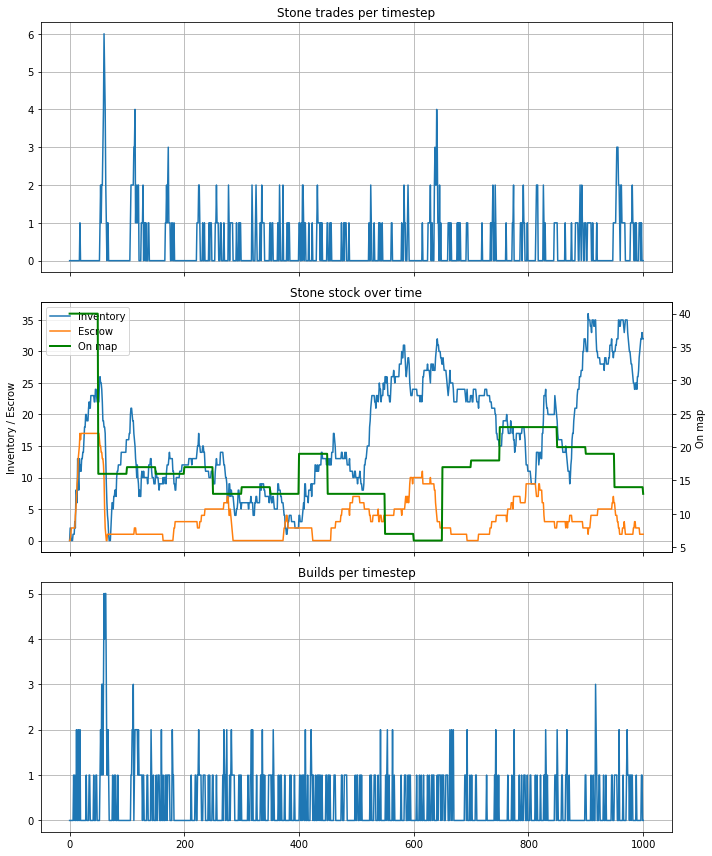

In [35]:
df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,22,25.50,9.57,22.0,59.0
1,1,45,9.70,3.05,11.0,54.0
2,2,45,24.44,6.53,7.0,41.0
3,3,57,19.12,5.73,8.5,30.0
4,4,31,19.45,7.93,12.5,36.0
5,5,35,20.12,5.50,13.5,28.0
6,6,37,10.92,7.05,15.5,37.0
7,7,49,12.96,3.91,22.0,19.0
8,8,32,10.91,8.18,20.5,25.0
9,9,42,11.92,3.83,18.0,36.0


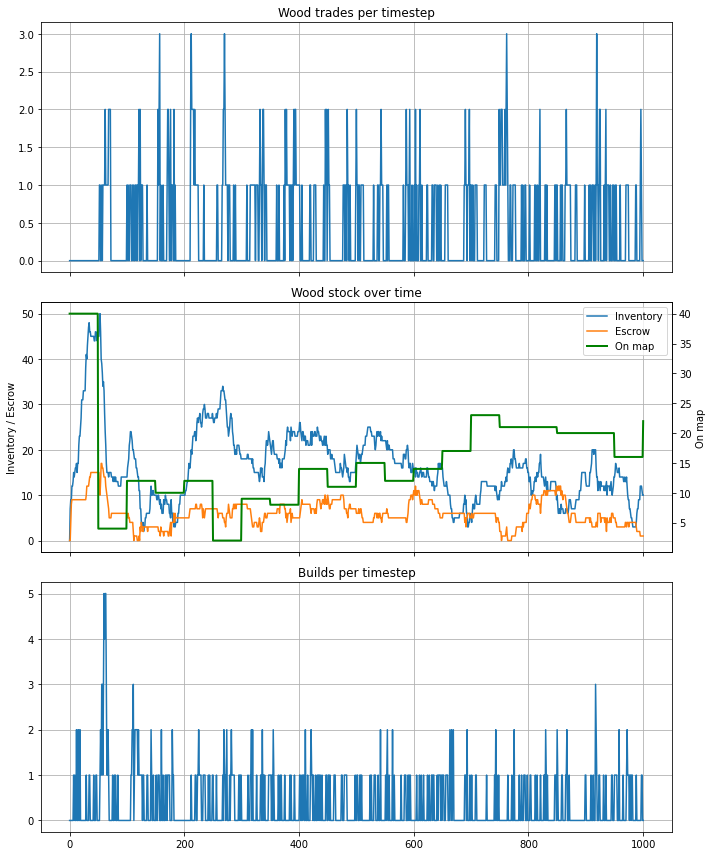

In [36]:
df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Wood", period=100)
df_wood_p

In [37]:
df_inv = plotting.inventory_table_by_tax_period(dense_log0, period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,None,146.000000,0.0,8.0,31.0,1.0,0.0,177.000000,1.0,8.0
1,1,99,1,None,28.000000,0.0,4.0,30.0,1.0,0.0,58.000000,1.0,4.0
2,1,99,2,None,111.000000,2.0,0.0,22.0,2.0,0.0,133.000000,4.0,0.0
3,1,99,3,None,0.000000,0.0,0.0,7.0,0.0,1.0,7.000000,0.0,1.0
4,1,99,4,None,166.000000,5.0,0.0,18.0,0.0,0.0,184.000000,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,None,674.080312,0.0,16.0,30.0,0.0,0.0,704.080312,0.0,16.0
76,10,999,4,None,816.174063,8.0,3.0,15.0,1.0,0.0,831.174063,9.0,3.0
77,10,999,5,None,634.996562,1.0,0.0,18.0,0.0,0.0,652.996562,1.0,0.0
78,10,999,6,None,888.515312,0.0,1.0,15.0,0.0,0.0,903.515312,0.0,1.0


In [38]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,177.000000,58.000000,133.000000,7.000000,184.000000,68.000000,96.000000,44.000000
2,277.053437,169.357188,204.957187,211.632187,228.971875,143.519375,222.589375,175.919375
3,344.470937,252.604688,257.374687,454.549688,282.244375,197.651875,286.411875,300.691875
4,431.775625,291.989375,307.209375,403.025625,447.566875,288.274375,380.664375,347.494375
5,519.798437,363.248438,357.068438,518.884688,463.626875,344.964375,461.724375,520.684375
6,619.693437,423.503438,396.823438,525.979687,581.883437,424.368438,517.580938,463.167187
7,628.243437,475.653437,478.973437,578.129688,619.446250,490.011250,681.123750,631.418750
8,667.555937,516.965937,487.785937,569.692188,714.822813,595.187813,671.284063,657.705312
9,733.495312,563.905313,498.346563,570.252813,772.785313,617.600312,776.946562,689.667812


# comparison plots

In [39]:
def load_experiment_run(run_dir):
    import os, json, pickle

    with open(os.path.join(run_dir, "summary.json"), "r") as f:
        summary = json.load(f)

    dense_logs = None
    dense_log = None

    pkl_path = os.path.join(run_dir, "dense_logs_final.pkl")
    if os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            dense_logs = pickle.load(f)

        # keep old behavior too
        dense_log = dense_logs[0] if isinstance(dense_logs, dict) and 0 in dense_logs else None

    return {
        "run_dir": run_dir,
        "summary": summary,
        "dense_log": dense_log,
        "dense_logs": dense_logs,
    }

In [41]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028", #base
    #"travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__base_lux_20260504_221734",

    "travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728",

    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__high_travel_cost_20260507_102202",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__higher_travel_cost_20260508_172058",
    "travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost_20260509_231304",
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

# all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
# for i, folder in enumerate(all_folders):
#     print(f"{i}: {folder}")

# selected_idx = [0, 1, 2]

# run_dirs_idx = [
#     os.path.join(BASE_RESULTS_DIR, all_folders[i])
#     for i in selected_idx
# ]

# print(run_dirs)

In [42]:
import pickle
from pathlib import Path

run_dir = Path(run_dirs[0])

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

print(dense_logs.keys())
print(len(dense_logs))

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
20


In [43]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
if str(PROJECT_ROOT / "tutorials") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "tutorials"))

import simulation as exp

run_dir = Path(run_dirs[0])

with open(run_dir / "config.json", "r") as f:
    cfg = json.load(f)

env_obj_phase3b = exp.create_env(cfg["env_config_dict_phase3b"])


In [44]:
# def load_experiment_run(run_dir):
#     with open(os.path.join(run_dir, "summary.json"), "r") as f:
#         summary = json.load(f)

#     metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

#     with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
#         dense_logs = pickle.load(f)

#     # choose one representative dense log for single-rollout plots
#     if isinstance(dense_logs, dict) and 0 in dense_logs:
#         dense_log = dense_logs[0]
#     else:
#         dense_log = dense_logs

#     return {
#         "run_dir": run_dir,
#         "name": summary.get("experiment_name", os.path.basename(run_dir)),
#         "summary": summary,
#         "metrics": metrics,
#         "dense_logs": dense_logs,   # all dense logs
#         "dense_log": dense_log,     # one example dense log
#     }
# def load_experiment_runs(run_dirs):
#     return [load_experiment_run(rd) for rd in run_dirs]

In [45]:
runs = plotting.load_experiment_runs(run_dirs)

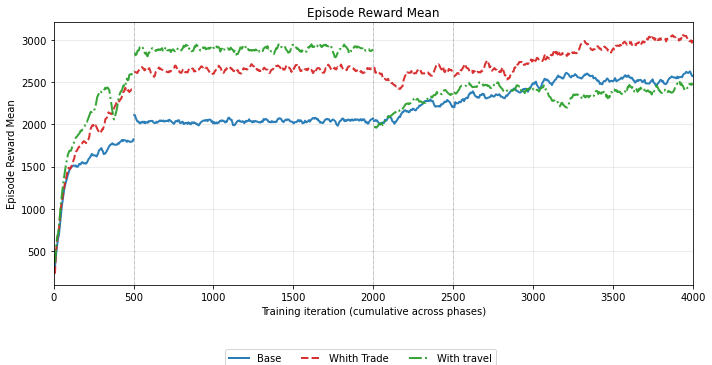

In [46]:
fig = plotting.compare_training_curves(
    runs,
    metric="episode_reward_mean",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=5,
)

In [47]:
# fig = plotting.compare_training_curves(
#     runs,
#     metric="social_welfare_coin_eq_times_prod",
#     short_labels=["No travel", "With travel"],
#     smooth_window=5,
# )

In [48]:
def plot_planner_rewards(run, smooth_window=25):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = run["metrics"].copy()
    df = df.reset_index(drop=True)
    x = range(len(df))

    fig, ax = plt.subplots(figsize=(10, 5))

    for col in ["policy_reward_mean/p_top", "policy_reward_mean/p_bottom"]:
        y = df[col].astype(float)
        if smooth_window > 1:
            y = y.rolling(smooth_window, min_periods=1).mean()
        ax.plot(x, y, label=col)

    ax.set_title("Planner policy rewards")
    ax.set_xlabel("Training row")
    ax.set_ylabel("Mean policy reward")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig

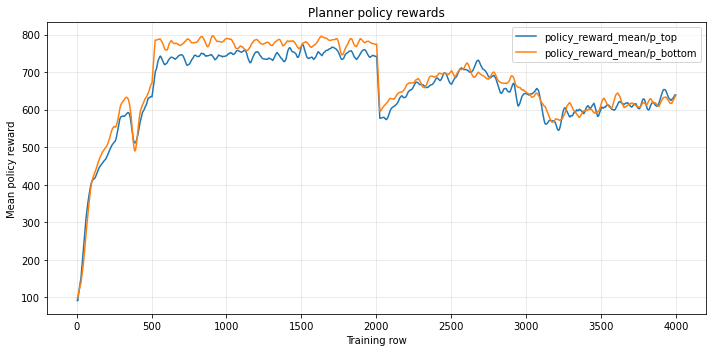

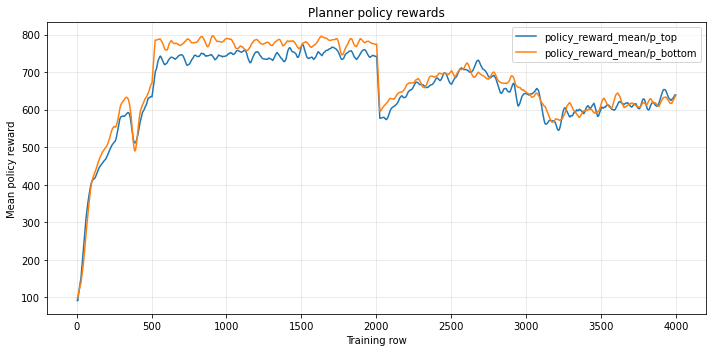

In [49]:
plot_planner_rewards(runs[2])

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,733.375,109.129131,233.87375,755,365,5867.0,0,4,4,travel-off__regionaltrade-on__layout-stacked_5...,500,1500,500,1500
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,914.000,114.003476,297.86000,1303,422,7312.0,0,4,4,travel-off__regionaltrade-off__layout-stacked_...,500,1500,500,1500
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost,With travel,660.125,203.618211,240.46000,959,308,5281.0,8,2,6,travel-on__regionaltrade-off__layout-stacked_5...,500,1500,500,1500


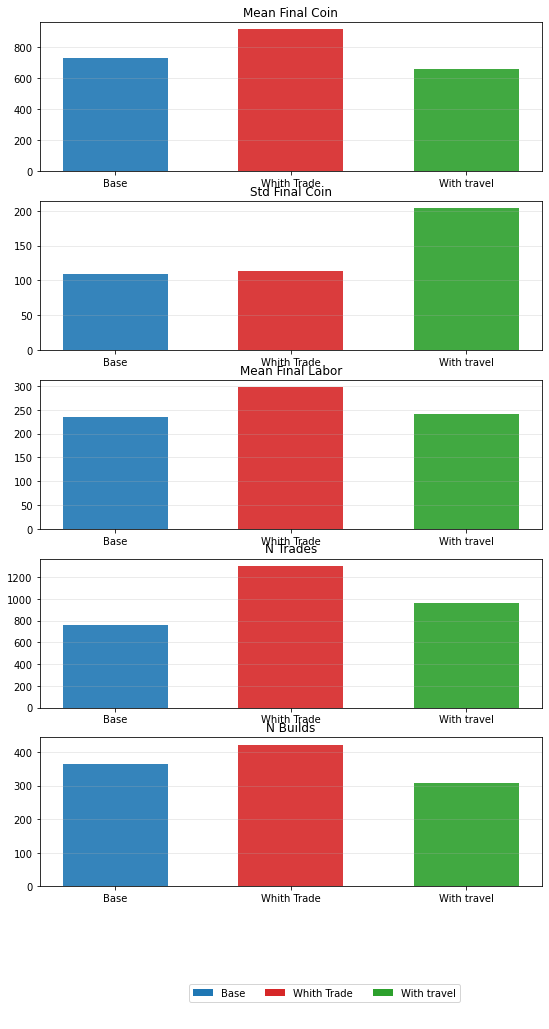

In [50]:
fig_single, out_single = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
)

out_single

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,733.375,109.129131,233.87375,755,365,5867.0,0,4,4,travel-off__regionaltrade-on__layout-stacked_5...,500,1500,500,1500
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,914.000,114.003476,297.86000,1303,422,7312.0,0,4,4,travel-off__regionaltrade-off__layout-stacked_...,500,1500,500,1500
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost,With travel,660.125,203.618211,240.46000,959,308,5281.0,8,2,6,travel-on__regionaltrade-off__layout-stacked_5...,500,1500,500,1500


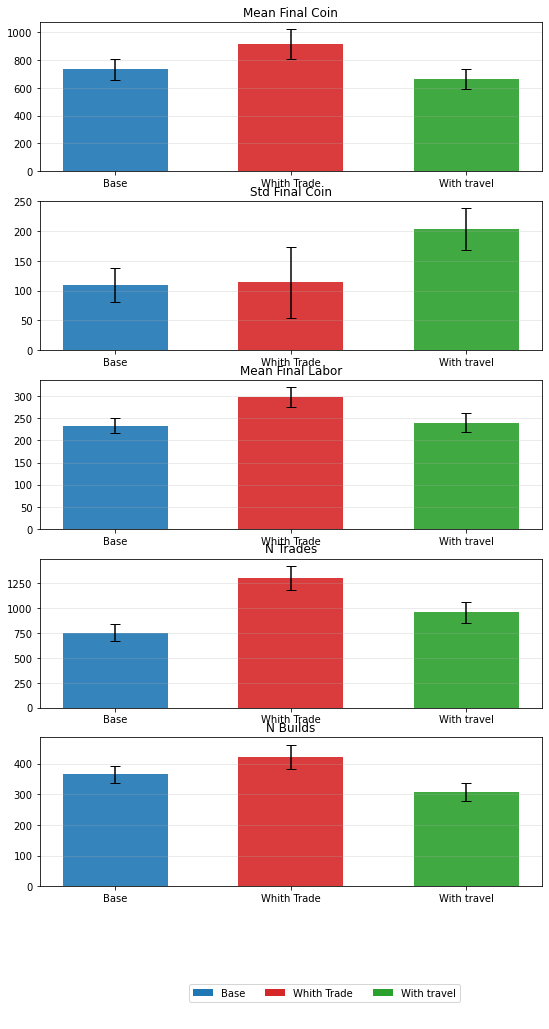

In [51]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar="std",  
)

out_avg

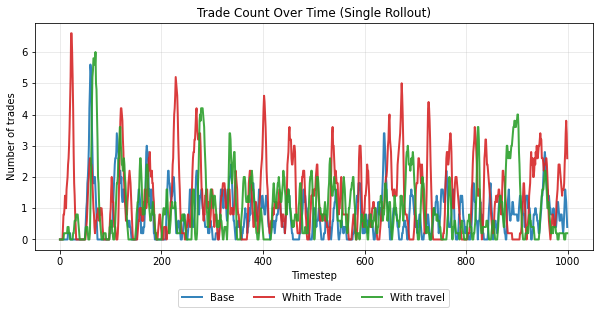

In [52]:
fig_single = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="single",
    smooth_window=5,  
)

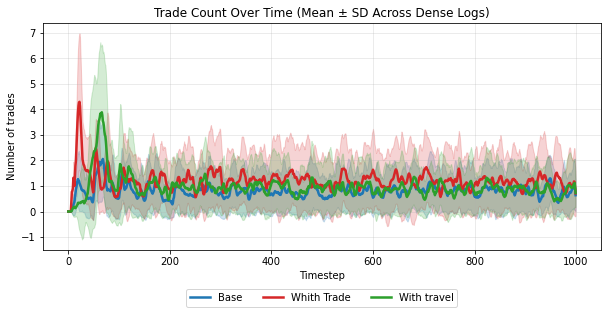

In [53]:
fig_avg = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="average",
    smooth_window=5,
)

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,0.083848,NaN,1
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,0.067655,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost,With travel,0.146481,NaN,1


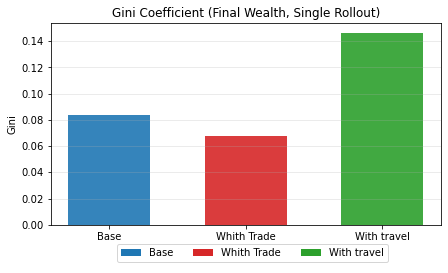

In [54]:
fig_single, out_single = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,0.081157,0.025311,20
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,0.098910,0.040942,20
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost,With travel,0.102742,0.027294,20


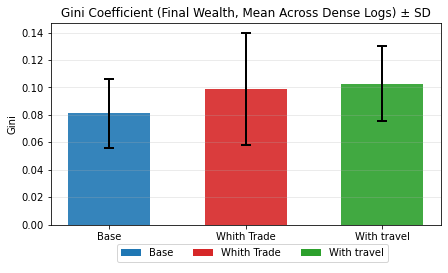

In [55]:
fig_avg, out_avg = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

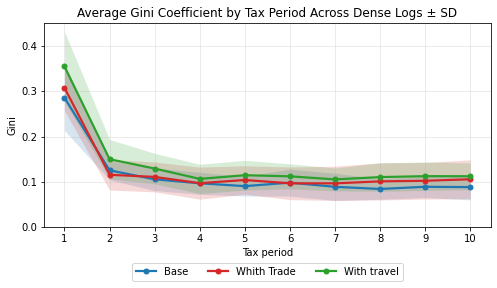

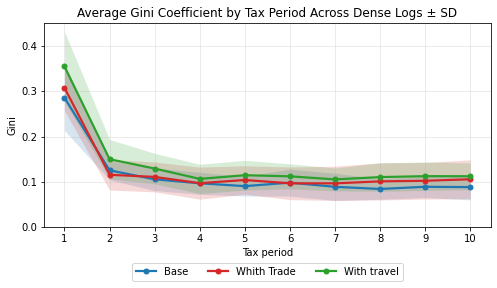

In [56]:
import importlib
importlib.reload(plotting)

runs = plotting.load_experiment_runs(run_dirs)

fig_gini_periods, gini_periods, gini_periods_raw = plotting.compare_gini_over_tax_periods(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    period=100,
    max_periods=10,
    errorbar="std",
    show_legend=True,
)

#gini_periods
fig_gini_periods



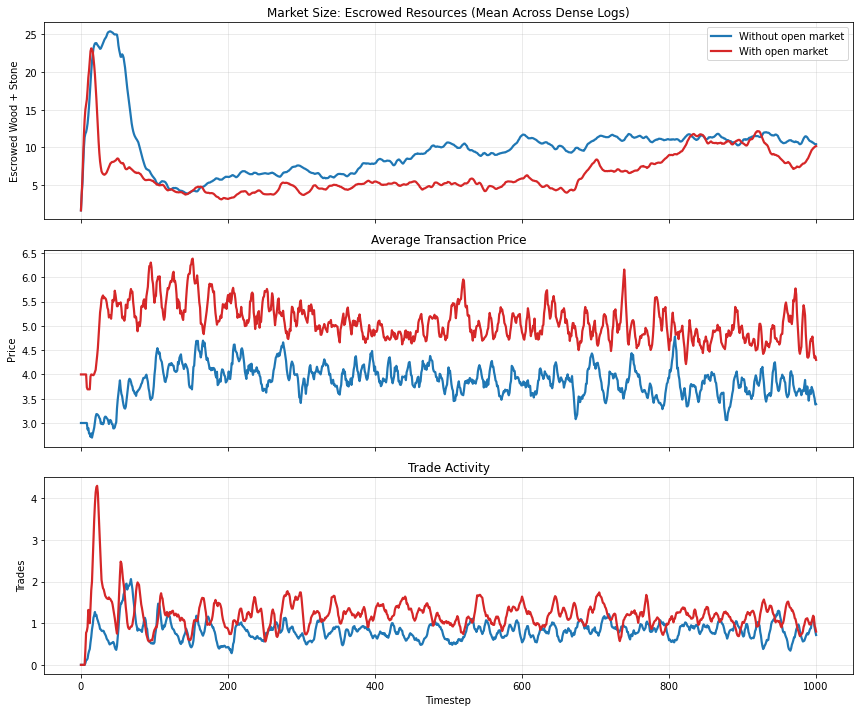

In [57]:
fig_market_open, df_market_open = plotting.compare_market_size_prices_trade_activity(
    runs[:2],
    short_labels=["Without open market", "With open market"],
    resources=("Wood", "Stone"),
    mode="average",
    smooth_window=5,
)


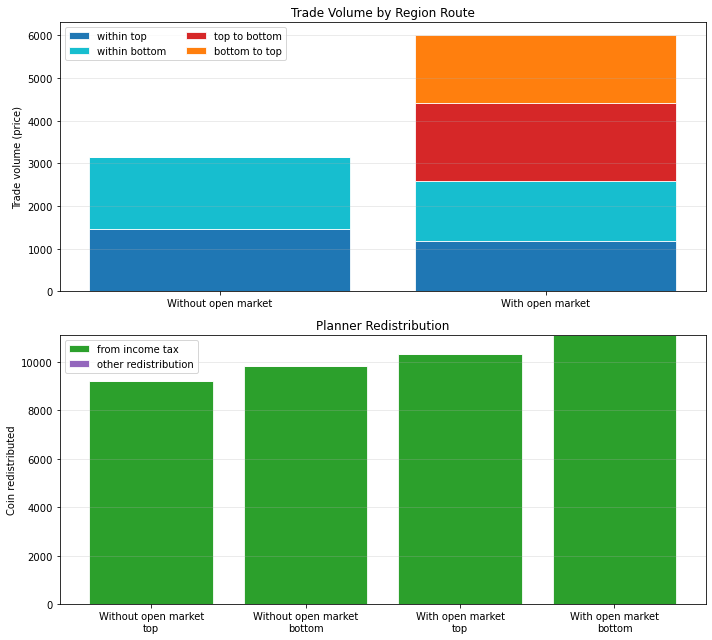

In [58]:
fig, trade_df, redist_df = plotting.plot_regional_trade_and_planner_redistribution(
    runs[:2],
    short_labels=["Without open market", "With open market"],
    mode="average",
)


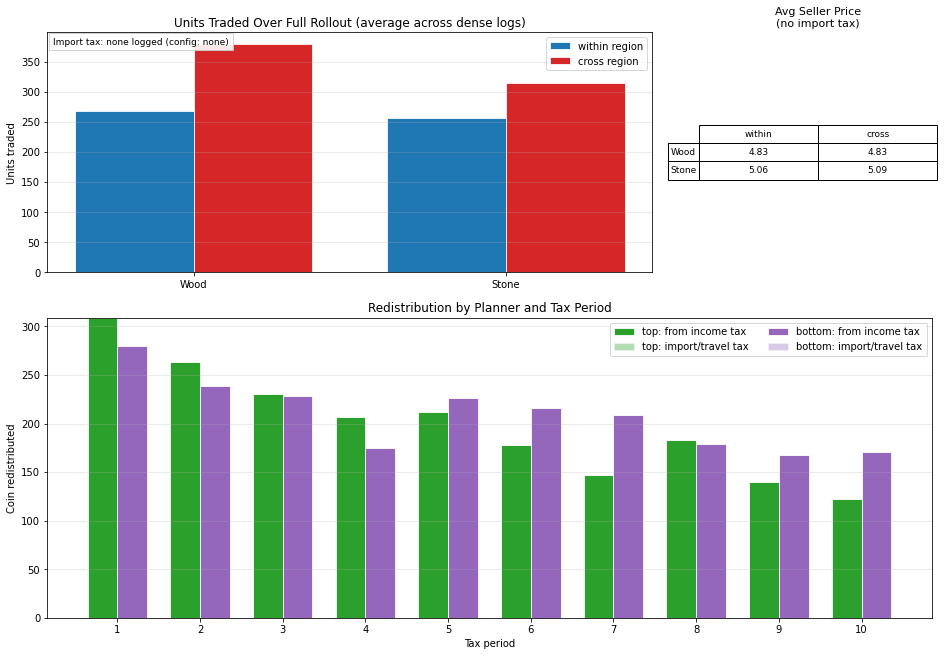

In [59]:
fig, units, prices, redist = plotting.plot_trade_enabled_run_trade_and_redistribution(
    runs[1],
    mode="average",   # or "average"
)


In [60]:
usd_scaling = 1000
eu_scaling = 1000 # 850 if in dolars

brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

# brackets = np.array([
#     0,
#     13200,
#     22050,
#     31100,
#     40300,
#     51750,
#     234850
# ]) / eu_scaling

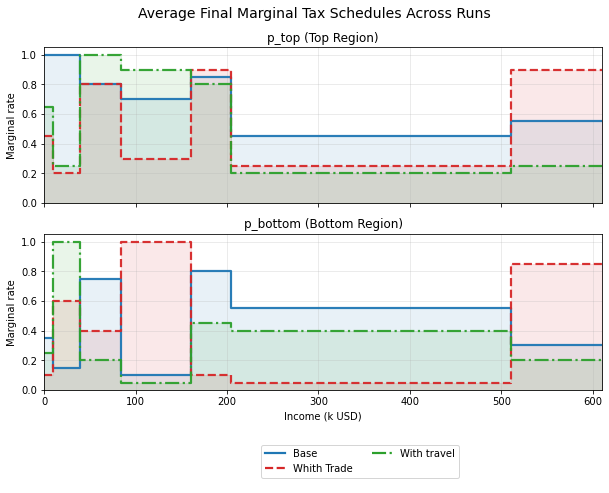

In [61]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

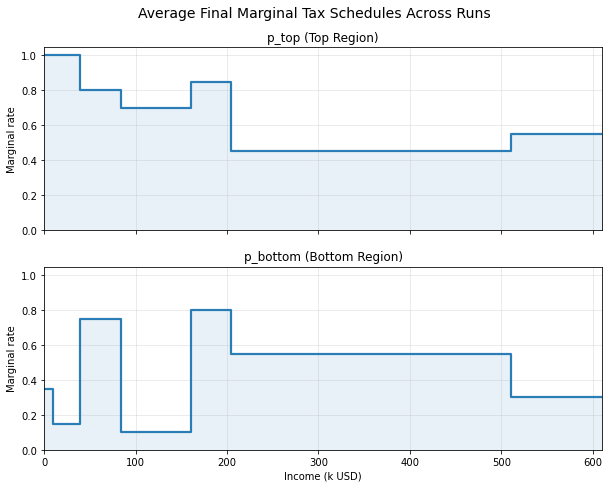

In [62]:
runs_single_no_compare = []

r_copy = runs[0].copy()
r_copy["dense_logs"] = {0: runs[0]["dense_log"]}
runs_single_no_compare.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single_no_compare,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    #short_labels=["No travel"],
    show_legend=False,
    errorbar=None,
    last_bin_width=100,
)

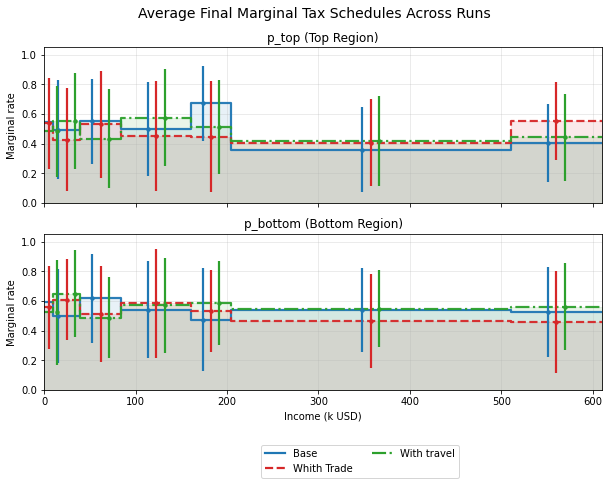

In [63]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)


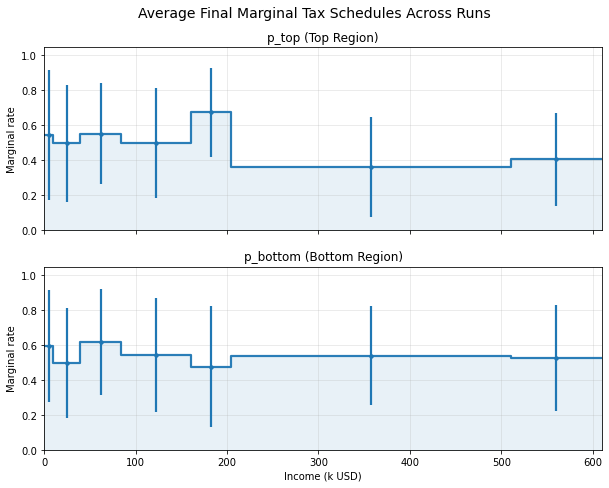

In [64]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    [runs[0]],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    show_legend=False,
    errorbar="std",  
    last_bin_width=100,
)

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from simulation import get_disc_rates

def plot_individual_final_tax_schedules(
    runs,
    env_obj,
    brackets,
    selected=None,          # None = all dense logs; or [(run_idx, log_key), ...]
    top_first=True,
    short_labels=None,
    last_bin_width=100,
    figsize=(10, 7),
):
    disc_rates = get_disc_rates(env_obj)
    brackets = np.asarray(brackets, dtype=float)

    right_edge = brackets[-1] + last_bin_width
    step_x = np.append(brackets, right_edge)

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    def extract_logs(run):
        if "dense_logs" in run:
            obj = run["dense_logs"]
        elif "dense_log" in run:
            obj = {0: run["dense_log"]}
        else:
            return {}

        if isinstance(obj, dict):
            return obj
        if isinstance(obj, list):
            return {i: log for i, log in enumerate(obj)}
        return {}

    def split_last(arr):
        last = np.asarray(arr)[-1]
        half = last.shape[0] // 2
        if top_first:
            return last[:half], last[half:]
        else:
            return last[half:], last[:half]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    plot_i = 0

    for run_idx, run in enumerate(runs):
        logs = extract_logs(run)

        run_label = (
            short_labels[run_idx]
            if short_labels is not None
            else run.get("name", f"run {run_idx}")
        )

        for log_key, dense_log in logs.items():
            if selected is not None and (run_idx, log_key) not in selected:
                continue

            planner_actions = dense_log["planner_actions"]

            top_actions, _ = split_last(planner_actions["p_top"])
            _, bottom_actions = split_last(planner_actions["p_bottom"])

            top_rates = disc_rates[np.clip(top_actions.astype(int), 0, len(disc_rates) - 1)]
            bottom_rates = disc_rates[np.clip(bottom_actions.astype(int), 0, len(disc_rates) - 1)]

            top_step_y = np.append(top_rates, top_rates[-1])
            bottom_step_y = np.append(bottom_rates, bottom_rates[-1])

            color = colors[plot_i % len(colors)]
            label = f"{run_label}, log {log_key}"

            axes[0].step(step_x, top_step_y, where="post", color=color, linewidth=1.8, label=label)
            axes[1].step(step_x, bottom_step_y, where="post", color=color, linewidth=1.8, label=label)

            plot_i += 1

    axes[0].set_title("p_top final tax schedules")
    axes[0].set_ylabel("Marginal rate")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("p_bottom final tax schedules")
    axes[1].set_xlabel("Income")
    axes[1].set_ylabel("Marginal rate")
    axes[1].grid(True, alpha=0.3)

    axes[1].set_xlim(brackets[0], right_edge)

    fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, fontsize=9)
    fig.subplots_adjust(bottom=0.22, top=0.92)

    return fig
 

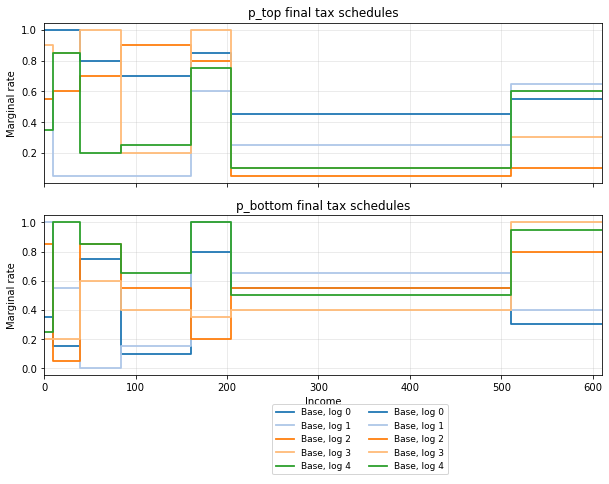

In [66]:
fig = plot_individual_final_tax_schedules(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 0),   # run 0, dense log key 0
        (0, 1),   # run 0, dense log key 1
        (0, 2),   # run 0, dense log key 2
        (0, 3),   # run 0, dense log key 3
        (0, 4),   # run 0, dense log key 4
    ],
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    last_bin_width=100,
)


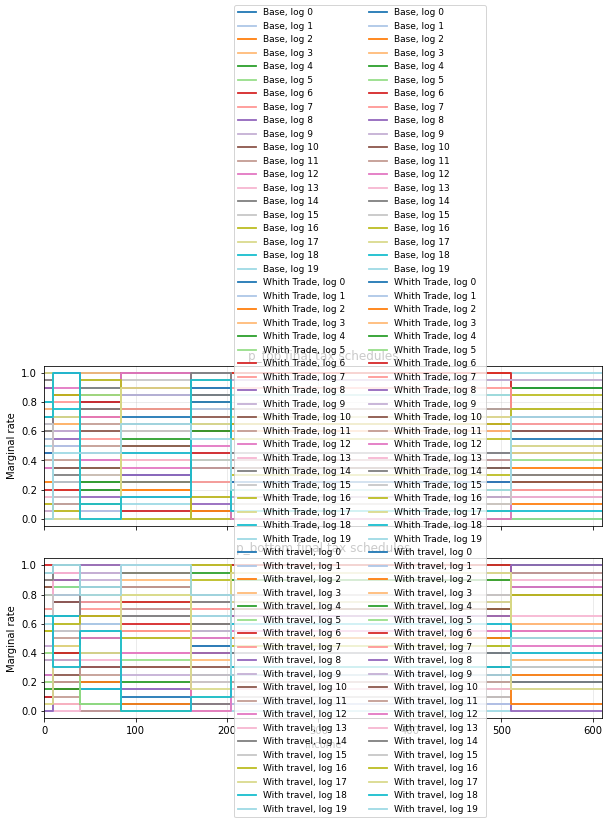

In [67]:
fig = plot_individual_final_tax_schedules(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    last_bin_width=100,
)


# same run comparison

No travel, log 0
planner_region counts:
top       4
bottom    4
final_location_region counts:
top       4
bottom    4



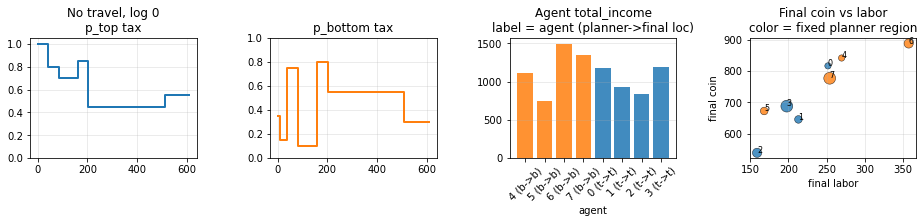

In [68]:
fig = plotting.plot_tax_and_agent_behavior_for_logs(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 0),
        #(0, 10),
        # (1, 2),
    ],
    top_first=True,
    short_labels=["No travel", "With travel"],
    behavior_metric="total_income",   # try: final_coin, final_labor, move_distance, region_switches
    last_bin_width=100,
)

With travel, log 0
planner_region counts:
top       4
bottom    4
majority_location_region counts:
bottom    5
top       3
final_location_region counts:
bottom    6
top       2
travel_events by agent:
agent
4    0
5    1
6    2
7    0
0    1
1    3
2    1
3    0



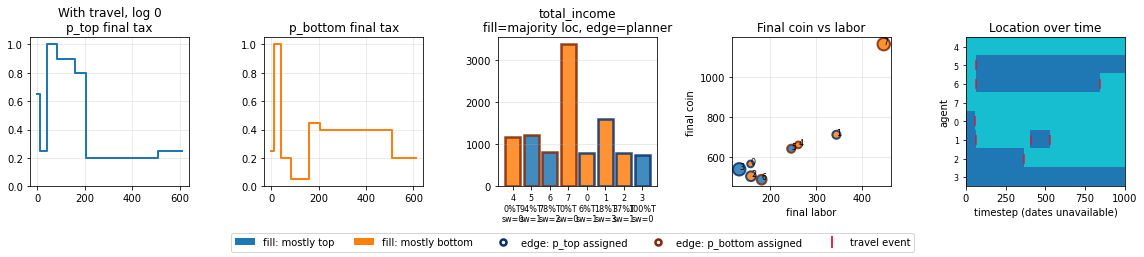

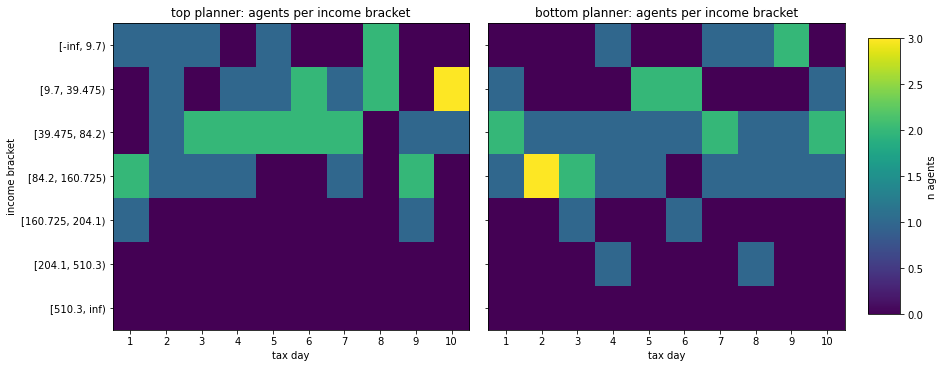

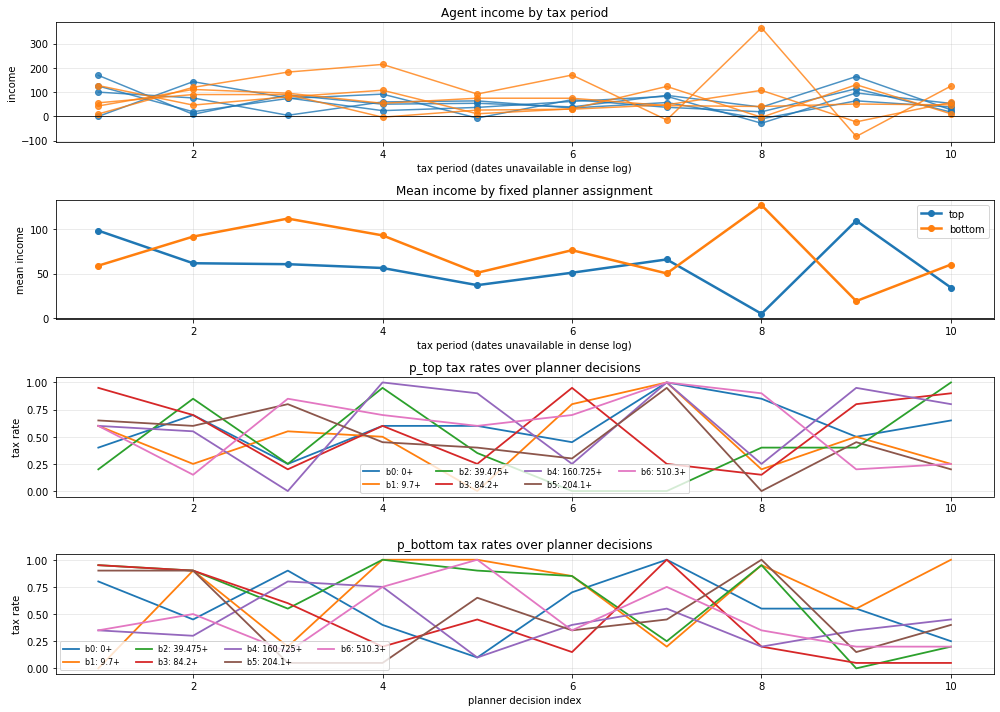

In [69]:
log = plotting._extract_logs_from_run(runs[2])[0]

fig_behavior = plotting.plot_tax_and_agent_behavior_for_logs_v2(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[(2, 0)],
    top_first=True,
    short_labels=["No travel", "With trade", "With travel"],
    behavior_metric="total_income", #"travel_events",
    last_bin_width=100,
)

fig_brackets, df_income, df_bracket_counts = plotting.plot_bracket_counts_for_log(
    log,
    brackets=brackets,
    period=100,
)

fig_time, df_income_time = plotting.plot_income_and_tax_over_time(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
)



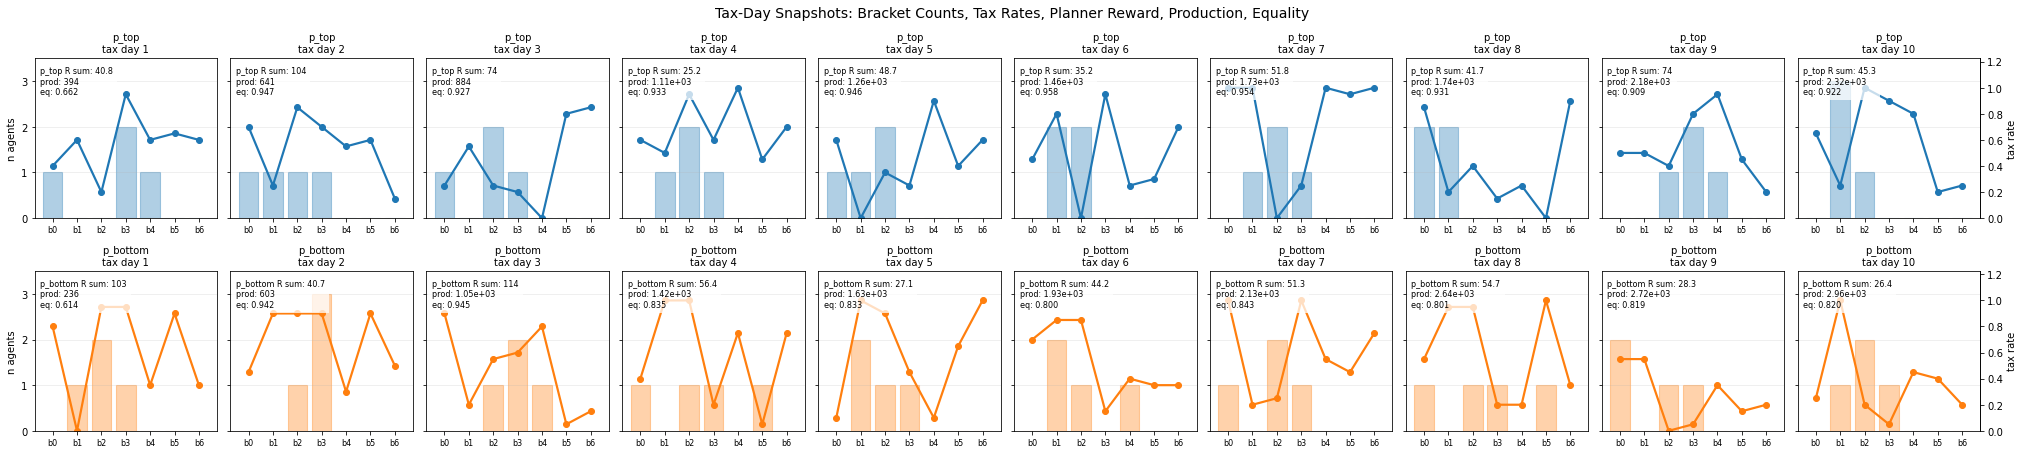

In [70]:
#log = plotting._extract_logs_from_run(runs[0])[0]


fig_snap, df_income_snap, df_counts_snap, df_swf_snap = plotting.plot_tax_bracket_snapshots_compact(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
)


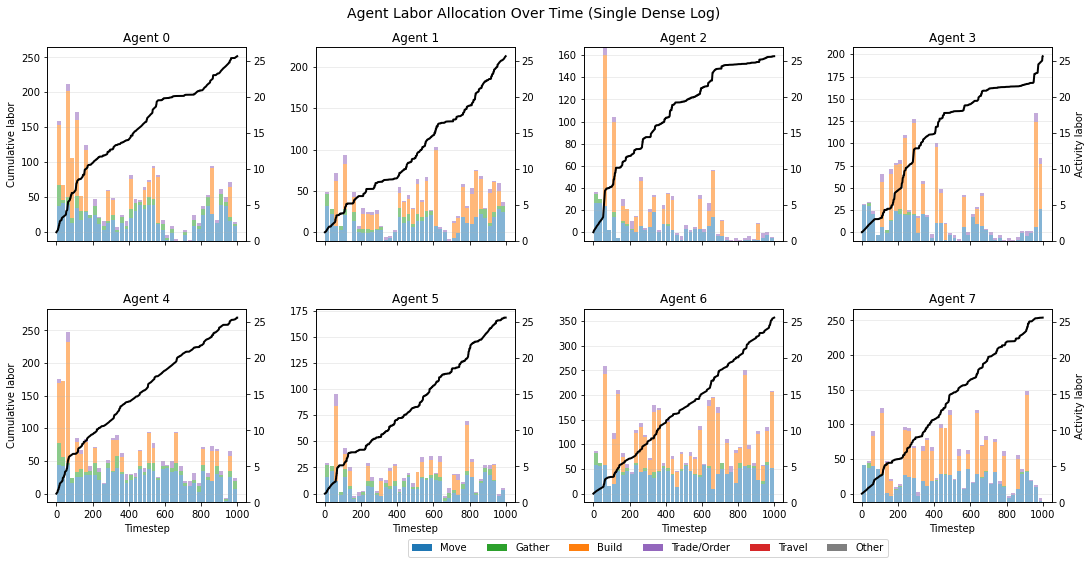

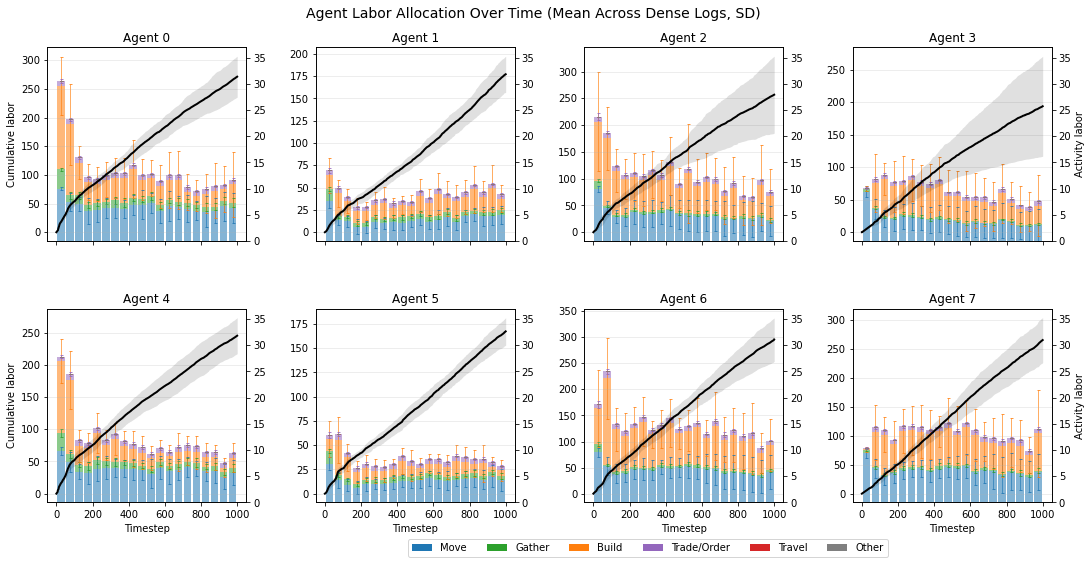

In [71]:
fig, summary_df, raw_alloc, raw_cumul = plotting.plot_agent_labor_allocation(
    dense_logs[0],
    mode="single",
    n_cols=4,
)

fig, summary_df, raw_allocation_df, raw_cumulative_df = plotting.plot_agent_labor_allocation(
    runs[0],
    mode="average",
    n_cols=4,
    bin_size=50,
)


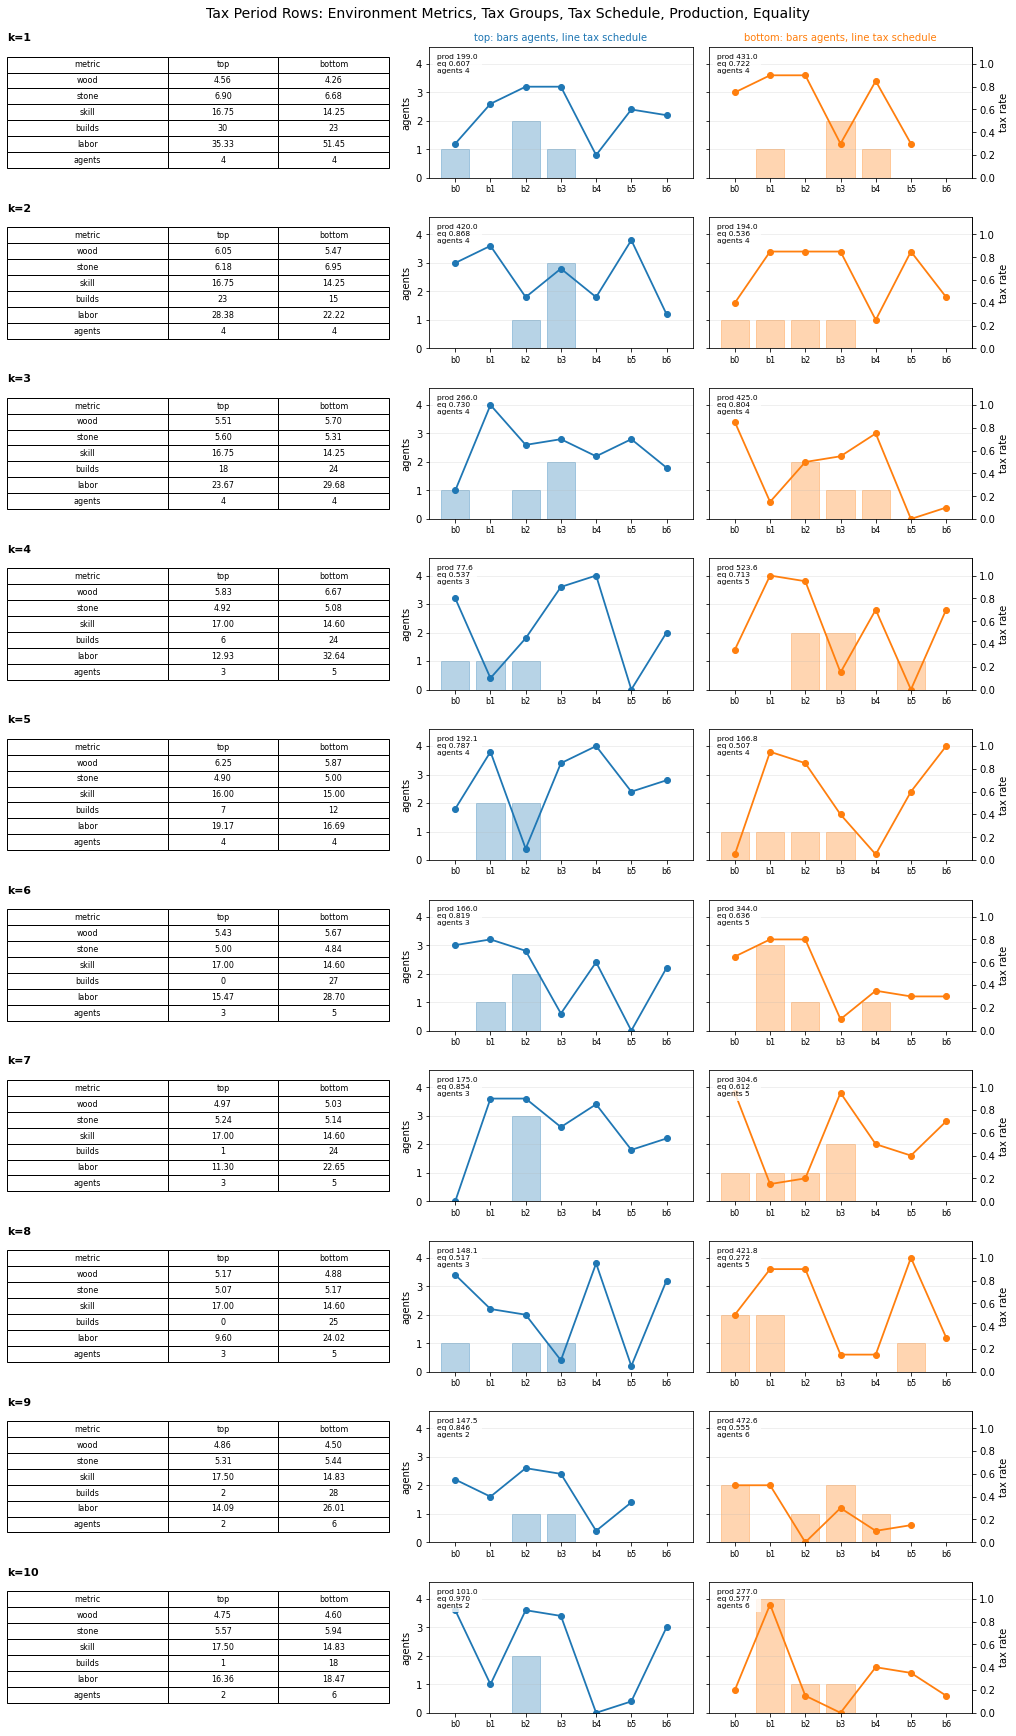

In [72]:
fig_rows, df_income, df_counts, df_outcomes, df_env, df_tax = plotting.plot_tax_period_rows_with_environment_metrics(
        log,
        brackets=brackets,
        period=100,
        n_snapshots=10,
        rate_disc=0.05,
    )


plt.show()


In [73]:
df_agent_tax, df_tax_periods = plotting.agent_tax_mobility_counterfactual_table(
    log,
    period=100,
    rate_disc=0.05,
)

df_agent_tax


,agent,skill_level,total_tax_paid_top_region,total_tax_paid_bottom_region,total_redistribution_top_region,total_redistribution_bottom_region,total_actual_tax_paid,total_counterfactual_tax_due_if_other_region,total_actual_minus_counterfactual_tax,net_tax_after_redistribution,n_tax_events_with_top_region,n_tax_events_with_bottom_region
0,0,11.0,0.00000,279.28500,0.000000,420.346792,279.28500,281.68000,-2.39500,-141.061792,0,10
1,1,13.0,23.65000,416.04625,25.450938,390.327417,439.69625,463.86125,-24.16500,23.917896,1,9
2,2,16.0,141.89250,24.40500,154.185000,261.109292,166.29750,190.24250,-23.94500,-248.996792,3,7
3,3,22.0,362.04500,0.00000,362.894896,0.000000,362.04500,340.96000,21.08500,-0.849896,10,0
4,4,11.0,0.00000,377.69375,0.000000,420.346792,377.69375,409.25375,-31.56000,-42.653042,0,10
5,5,13.0,415.86875,0.00000,362.894896,0.000000,415.86875,459.34875,-43.48000,52.973854,10,0
6,6,16.0,213.60250,8.87500,301.633021,54.594167,222.47750,218.00625,4.47125,-133.749688,8,2
7,7,22.0,0.00000,810.76625,0.000000,420.346792,810.76625,806.28500,4.48125,390.419458,0,10


In [74]:
latex_table = df_agent_tax.to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    caption="Comparison of ML Model Performance Metrics",  # The caption to appear above the table in the LaTeX document
    label="tab:model_comparison",  # A label used for referencing the table within the LaTeX document
    position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lccc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
)

print(latex_table)

\begin{table}[htbp]
\centering
\caption{Comparison of ML Model Performance Metrics}
\label{tab:model_comparison}
\begin{tabular}{lccc}
\toprule
 agent &  skill_level &  total_tax_paid_top_region &  total_tax_paid_bottom_region &  total_redistribution_top_region &  total_redistribution_bottom_region &  total_actual_tax_paid &  total_counterfactual_tax_due_if_other_region &  total_actual_minus_counterfactual_tax &  net_tax_after_redistribution &  n_tax_events_with_top_region &  n_tax_events_with_bottom_region \\
\midrule
     0 &        11.00 &                       0.00 &                        279.29 &                             0.00 &                              420.35 &                 279.29 &                                        281.68 &                                  -2.39 &                       -141.06 &                             0 &                               10 \\
     1 &        13.00 &                      23.65 &                        416.05 &                   

# debug and DF

In [75]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\results\travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028\training_metrics.csv")
cols = [c for c in df.columns if "reward" in c.lower() or "p_top" in c or "p_bottom" in c]
df[cols].tail(20)

,episode_reward_mean,episode_reward_min,episode_reward_max,policy_reward_mean/p_top,policy_reward_mean/p_bottom,policy_reward_mean/a
3980,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3981,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3982,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3983,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3984,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3985,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3986,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3987,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3988,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3989,2580.148370,1890.445560,3066.794823,657.497871,664.069651,157.322606


In [76]:
def inspect_planner_rewards(log):
    if "planner_rewards" not in log:
        print("No planner_rewards in dense log.")
        return

    for pid in ["p_top", "p_bottom"]:
        arr = np.array(log["planner_rewards"].get(pid, []), dtype=float)
        print(pid)
        print("  len:", len(arr))
        print("  finite:", np.isfinite(arr).all() if len(arr) else None)
        print("  min/max/mean/sum:", 
              np.nanmin(arr) if len(arr) else None,
              np.nanmax(arr) if len(arr) else None,
              np.nanmean(arr) if len(arr) else None,
              np.nansum(arr) if len(arr) else None)
        print("  nonzero count:", np.sum(np.abs(arr) > 1e-9) if len(arr) else 0)

In [77]:
inspect_planner_rewards(dense_logs[0])

p_top
  len: 1000
  finite: True
  min/max/mean/sum: -4.1666666666666 32.92802083333221 0.599504791666667 599.5047916666671
  nonzero count: 337
p_bottom
  len: 1000
  finite: True
  min/max/mean/sum: -5.362500000000182 20.397708333332673 0.7353698958333336 735.3698958333335
  nonzero count: 373


In [78]:
def planner_rewards_at_tax_days(log, period=100):
    rows = []
    for pid in ["p_top", "p_bottom"]:
        arr = np.array(log.get("planner_rewards", {}).get(pid, []), dtype=float)
        for t, val in enumerate(arr):
            rows.append({
                "planner": pid,
                "t": t,
                "reward": val,
                "is_tax_day": (t % period == period - 1) or (t % period == 0),
            })
    return pd.DataFrame(rows)

dfr = planner_rewards_at_tax_days(dense_logs[0], period=100)
dfr.groupby(["planner", "is_tax_day"])["reward"].agg(["count", "mean", "sum", "min", "max"])

count      mean         sum       min        max
planner  is_tax_day                                                  
p_bottom False         980  0.657234  644.089167 -3.000000  17.500000
         True           20  4.564036   91.280729 -5.362500  20.397708
p_top    False         980  0.488607  478.834375 -4.166667  17.333333
         True           20  6.033521  120.670417 -2.500000  32.928021

In [79]:
from pathlib import Path
import pickle

run_dir = Path(run_dirs[2])  

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

df_income, df_tax_counts = plotting.tax_day_income_report(
    dense_logs[0],
    period=100,
)

df_income.head(16)

,tax_day_number,timestep,agent,region,state_region,location_region,split_row,coin_start,coin_end,income,tax_bracket
0,1,99,0,bottom,None,bottom,25,0.0,125.0000,125.0000,"[84.200, 160.725)"
1,1,99,1,bottom,None,bottom,25,0.0,169.0000,169.0000,"[160.725, 204.100)"
2,1,99,2,top,None,bottom,25,0.0,100.0000,100.0000,"[84.200, 160.725)"
3,1,99,3,top,None,bottom,25,0.0,0.0000,0.0000,"[0.000, 9.700)"
4,1,99,4,bottom,None,top,25,0.0,127.0000,127.0000,"[84.200, 160.725)"
5,1,99,5,top,None,top,25,0.0,43.0000,43.0000,"[39.475, 84.200)"
6,1,99,6,top,None,top,25,0.0,56.0000,56.0000,"[39.475, 84.200)"
7,1,99,7,bottom,None,top,25,0.0,10.0000,10.0000,"[9.700, 39.475)"
8,2,199,0,bottom,None,bottom,25,125.0,144.2850,19.2850,"[9.700, 39.475)"
9,2,199,1,bottom,None,bottom,25,169.0,177.6500,8.6500,"[0.000, 9.700)"


In [80]:
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[160.725, 204.100)",1
1,1,bottom,"[84.200, 160.725)",2
2,1,bottom,"[9.700, 39.475)",1
3,1,top,"[0.000, 9.700)",1
4,1,top,"[39.475, 84.200)",2
5,1,top,"[84.200, 160.725)",1
6,2,bottom,"[0.000, 9.700)",1
7,2,bottom,"[39.475, 84.200)",1
8,2,bottom,"[84.200, 160.725)",1
9,2,bottom,"[9.700, 39.475)",1


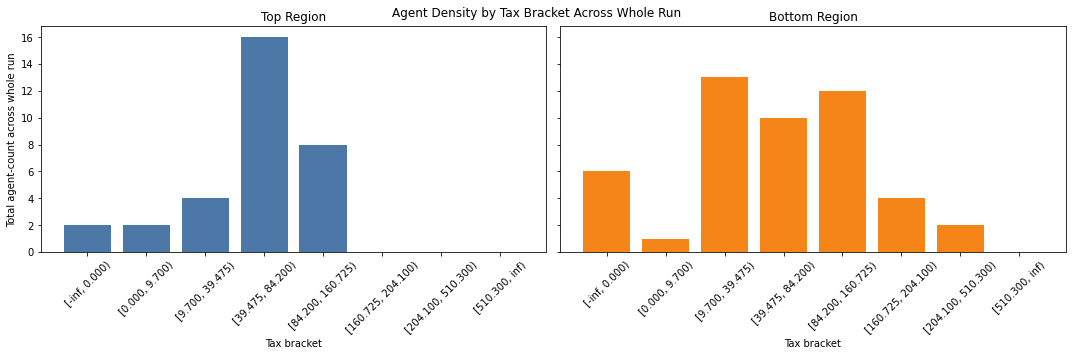

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_tax_counts.copy()
df["n_agents"] = pd.to_numeric(df["n_agents"], errors="coerce").fillna(0)

bracket_order = [
    "[-inf, 0.000)",
    "[0.000, 9.700)",
    "[9.700, 39.475)",
    "[39.475, 84.200)",
    "[84.200, 160.725)",
    "[160.725, 204.100)",
    "[204.100, 510.300)",
    "[510.300, inf)",
]

# bracket_order = [
#     "[-inf, 0.000)",
#     "[0, 13.200)",
#     "[13.200, 22.050)",
#     "[22.050, 31.100)",
#     "[31.100, 40.300)",
#     "[40.300, 51.750)",
#     "[51.750, 234.850)",
#     "[234.850 , inf)",
# ]


counts = (
    df.groupby(["region", "tax_bracket"])["n_agents"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=bracket_order, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

colors = {"top": "#4C78A8", "bottom": "#F58518"}

for ax, region in zip(axes, ["top", "bottom"]):
    y = counts.loc[region] if region in counts.index else pd.Series(0, index=bracket_order)

    ax.bar(y.index, y.values, color=colors[region])
    ax.set_title(f"{region.capitalize()} Region")
    ax.set_xlabel("Tax bracket")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Total agent-count across whole run")

plt.suptitle("Agent Density by Tax Bracket Across Whole Run")
plt.tight_layout()
plt.show()


In [82]:
all_income = []
all_counts = []

for rollout_id, log in dense_logs.items():
    df_income, df_counts = plotting.tax_day_income_report(log, period=100)

    df_income["rollout_id"] = rollout_id
    df_counts["rollout_id"] = rollout_id

    all_income.append(df_income)
    all_counts.append(df_counts)

df_income_all = pd.concat(all_income, ignore_index=True)
df_tax_counts_all = pd.concat(all_counts, ignore_index=True)

In [83]:
df_income_all.head(20)
df_tax_counts_all

,tax_day_number,region,tax_bracket,n_agents,rollout_id
0,1,bottom,"[160.725, 204.100)",1,0
1,1,bottom,"[84.200, 160.725)",2,0
2,1,bottom,"[9.700, 39.475)",1,0
3,1,top,"[0.000, 9.700)",1,0
4,1,top,"[39.475, 84.200)",2,0
...,...,...,...,...,...
1035,10,bottom,"[160.725, 204.100)",1,19
1036,10,bottom,"[84.200, 160.725)",2,19
1037,10,bottom,"[9.700, 39.475)",1,19
1038,10,top,"[39.475, 84.200)",2,19


In [84]:
import importlib
importlib.reload(plotting)


<module 'utils.plotting' from 'c:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

In [85]:
result_dir = r"results/travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"
#result_dir = r"results/travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728"
#result_dir = r"results/travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247"
#result_dir = r"results/travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__high_travel_cost_20260507_102202"


In [86]:
dense_log, dense_logs = plotting.get_dense_log_from_result_folder(result_dir, episode_key=0)

_______________:_ Agent  0 _____|_ Agent  4 _____|_ Agent  1 _____|_ Agent  5 _____|_ Agent  2 _____|_ Agent  6 _____|_ Agent  3 _____|_ Agent  7 ____
Cost (Wood)    :   4.83 (n= 60) |   4.83 (n= 46) |   4.45 (n= 49) |   4.82 (n= 51) |   4.83 (n= 58) |   5.00 (n= 62) |   4.68 (n= 59) |   4.75 (n= 87)
Cost (Stone)   :   3.25 (n= 48) |   2.94 (n= 34) |   3.00 (n= 26) |   2.95 (n= 21) |   2.97 (n= 62) |   3.18 (n= 78) |   2.89 (n= 88) |   2.87 (n=113)

Income (Wood)  :   4.69 (n=100) |   4.87 (n=125) |   5.07 (n= 15) |   4.97 (n= 31) |   4.70 (n= 77) |   4.71 (n= 66) |   4.62 (n= 34) |   4.88 (n= 24)
Income (Stone) :   2.79 (n= 73) |   2.93 (n= 60) |   3.15 (n=117) |   3.05 (n=146) |   2.96 (n= 25) |   2.60 (n= 15) |   2.89 (n=  9) |   2.92 (n= 25)
Income (Build) :  11.00 (n= 39) |  11.00 (n= 36) |  13.00 (n= 33) |  13.00 (n= 20) |  16.00 (n= 44) |  16.00 (n= 55) |  22.00 (n= 77) |  22.00 (n= 75)


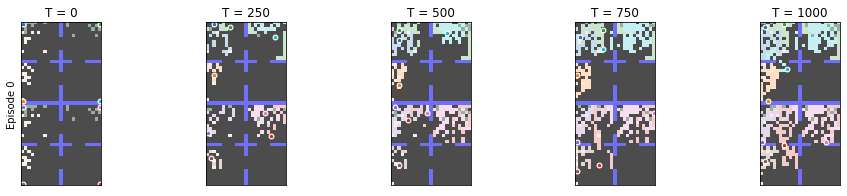

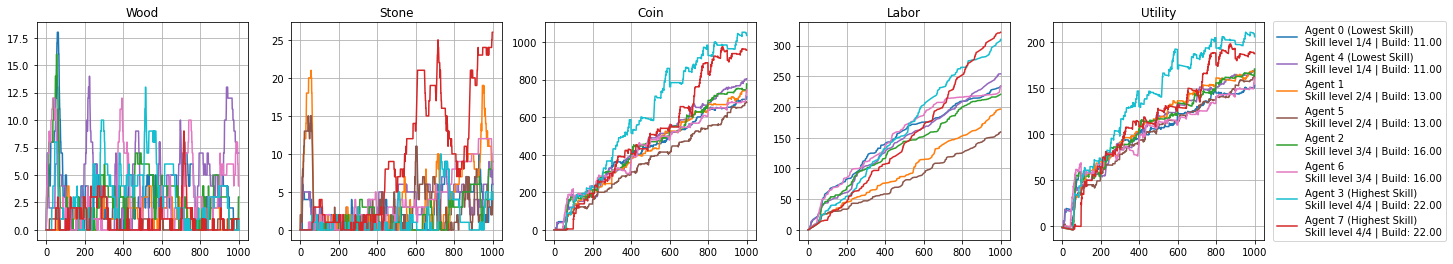

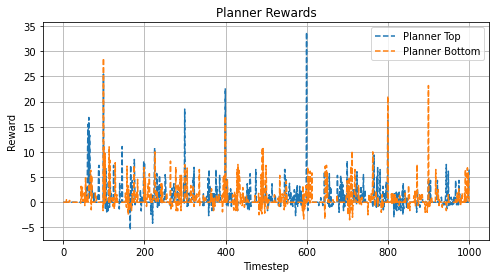

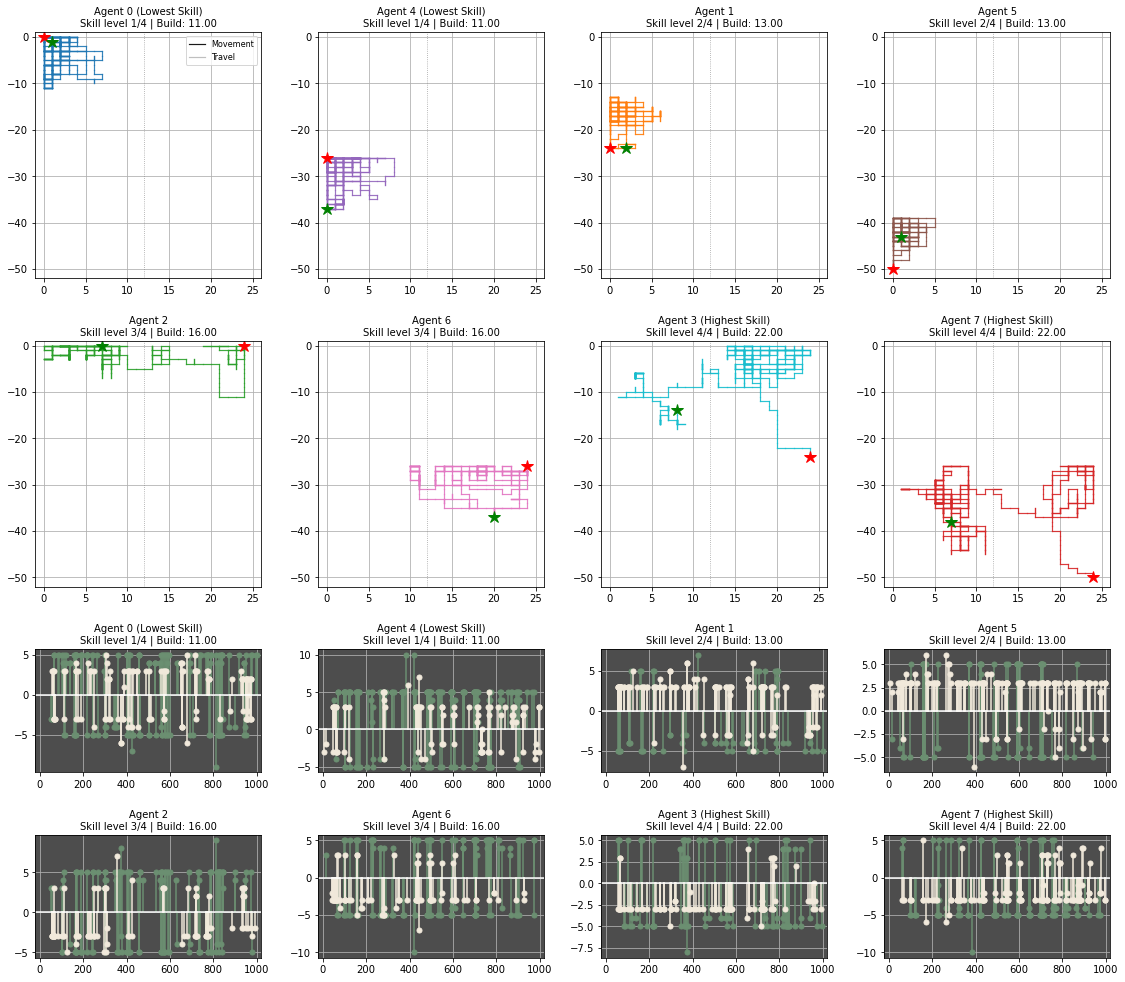

In [87]:
breakdown, dense_log, dense_logs = plotting.breakdown_all_agents_from_result_folder(
    result_dir,
    episode_key=5,
    #remap_key="build_payment"
)

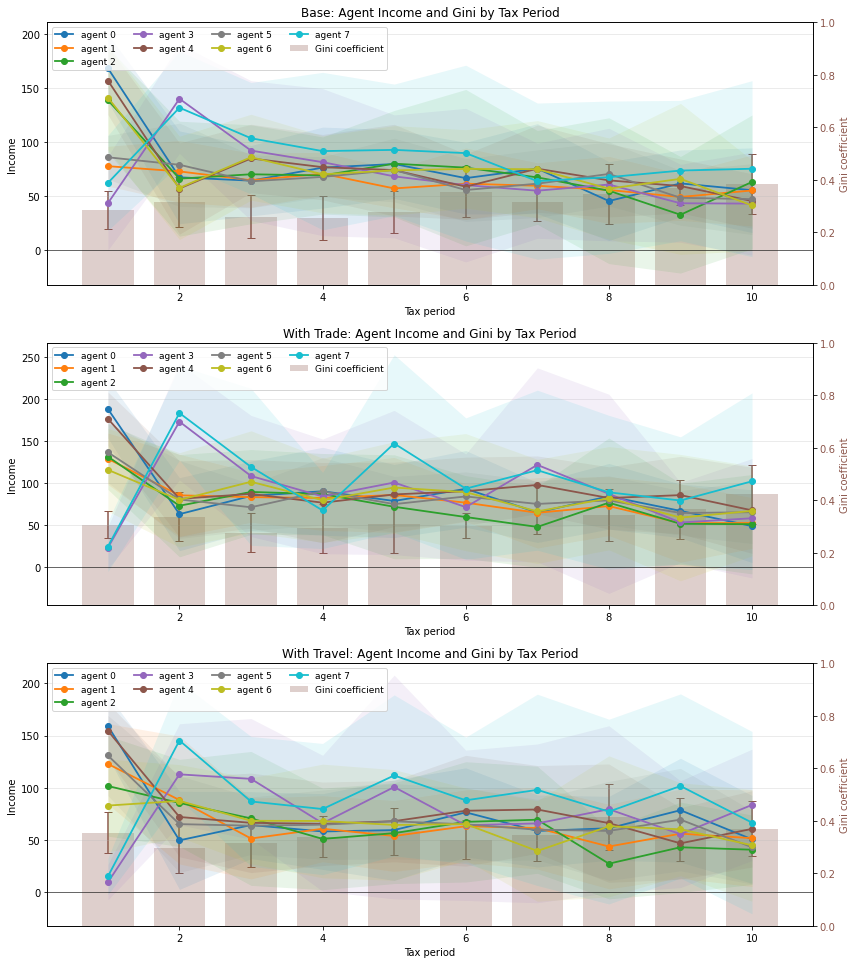

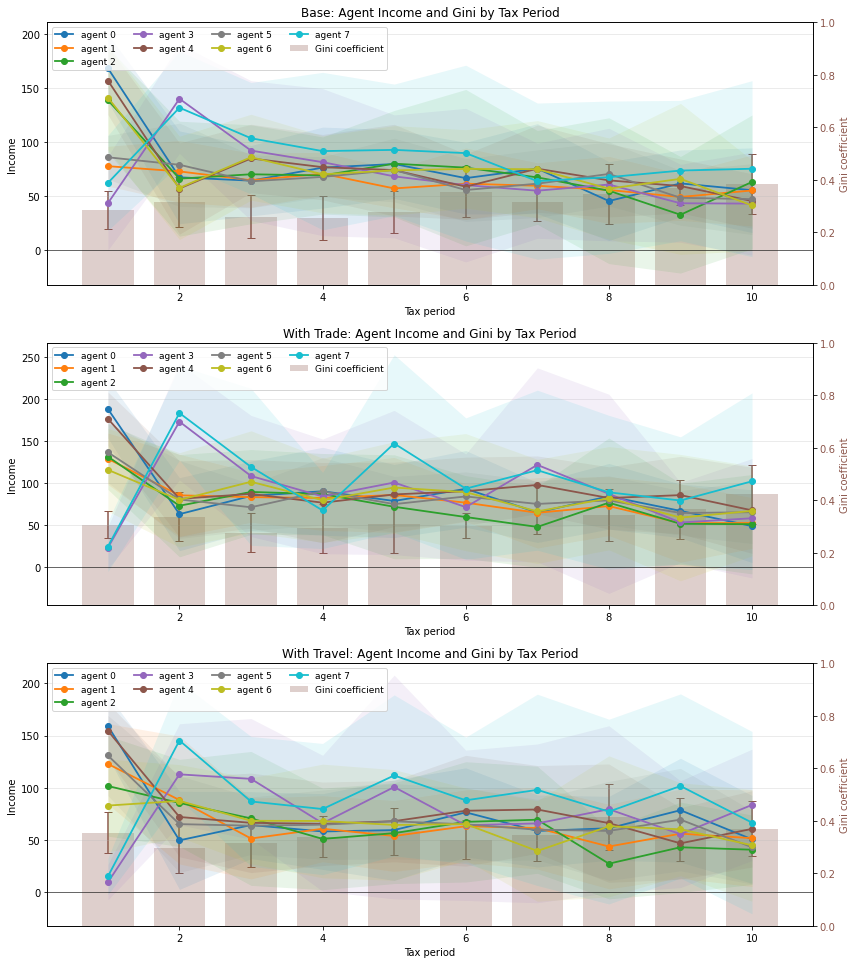

In [88]:
fig_income_gini, ax_income, ax_gini, income_summary, gini_summary, raw_income = (
    plotting.plot_agent_income_and_gini_for_runs(
        runs,
        short_labels=["Base", "With Trade", "With Travel"],
        period=100,
        max_periods=10,
        errorbar="std",
    )
)

fig_income_gini


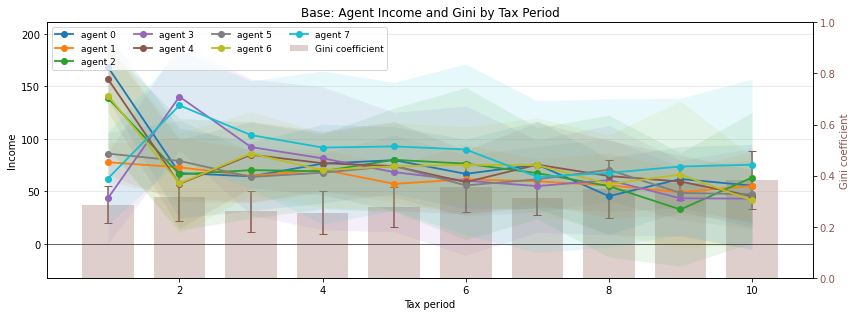

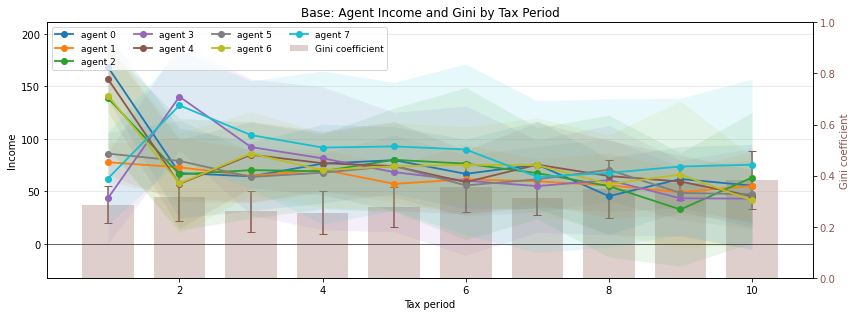

In [89]:
run = plotting.load_experiment_run(run_dirs[0])

fig, ax_income, ax_gini, income_summary, gini_summary, raw_income = (
    plotting.plot_agent_income_and_gini_for_run(
        run,
        label="Base",
        period=100,
        max_periods=10,
        errorbar="std",
    )
)

fig


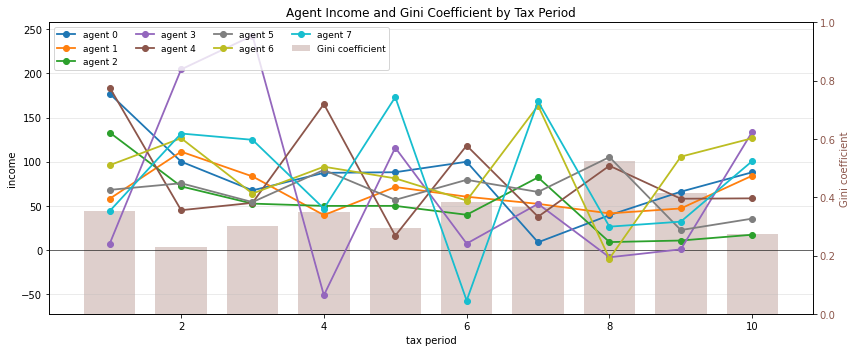

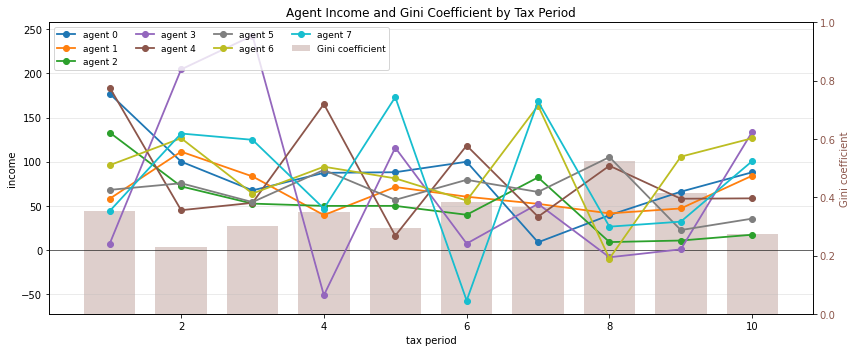

In [90]:
fig, ax_income, ax_gini, df_income, df_gini = (
    plotting.plot_agent_income_and_gini_for_dense_logs(
        dense_logs,
        episode_key=0,
        period=100,
        max_periods=10,
    )
)

fig

# Figuring out agent movement

In [91]:
df_agents, df_summary = plotting.diagnose_agent_activity_df(runs[0]["dense_log"])
df_agents

,agent,movement,coin,wood,stone,labor
0,0,555.0,816.139375,0.0,2.0,251.71
1,1,427.0,645.649375,0.0,10.0,213.10
2,2,298.0,539.259375,0.0,1.0,159.04
3,3,365.0,687.951875,0.0,16.0,197.92
4,4,688.0,841.247813,9.0,3.0,269.60
5,5,422.0,672.485313,1.0,0.0,168.33
6,6,787.0,887.509063,0.0,1.0,357.28
7,7,573.0,776.757812,1.0,0.0,254.01


In [92]:
all_summaries = []

for run in runs:
    _, df_sum = plotting.diagnose_agent_activity_df(run["dense_log"])
    df_sum["run"] = run["name"]
    all_summaries.append(df_sum)

df_all = pd.concat(all_summaries, ignore_index=True)
df_all

,steps,n_builds,n_trades,n_gathers,avg_movement,total_coin,total_wood,total_stone,run
0,1000,365,755,514,514.375,5867.0,11.0,33.0,travel-off__regionaltrade-on__layout-stacked_5...
1,1000,422,1303,602,702.625,7312.0,28.0,37.0,travel-off__regionaltrade-off__layout-stacked_...
2,1000,308,959,490,548.375,5281.0,32.0,84.0,travel-on__regionaltrade-off__layout-stacked_5...


In [93]:
# usd_scaling = 1000
# brackets = np.array([
#     0,
#     9700,
#     39475,
#     84200,
#     160725,
#     204100,
#     510300
# ]) / usd_scaling

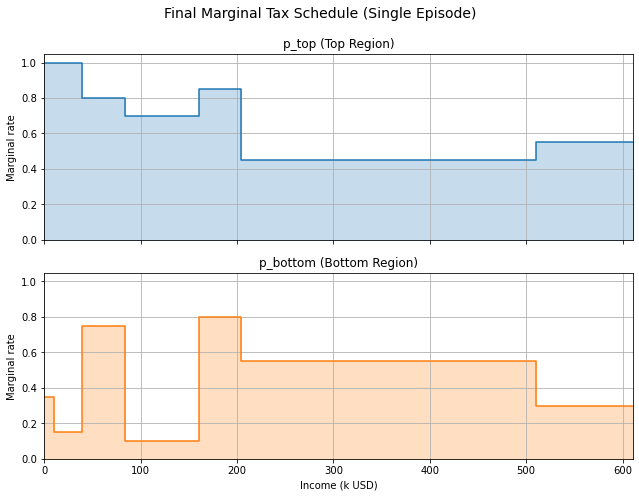

In [94]:
single_dense_log = {0: dense_logs[0]}  # keep only episode 0

fig_single = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=single_dense_log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final Marginal Tax Schedule (Single Episode)",
    errorbar=None,  
    last_bin_width=100,
)

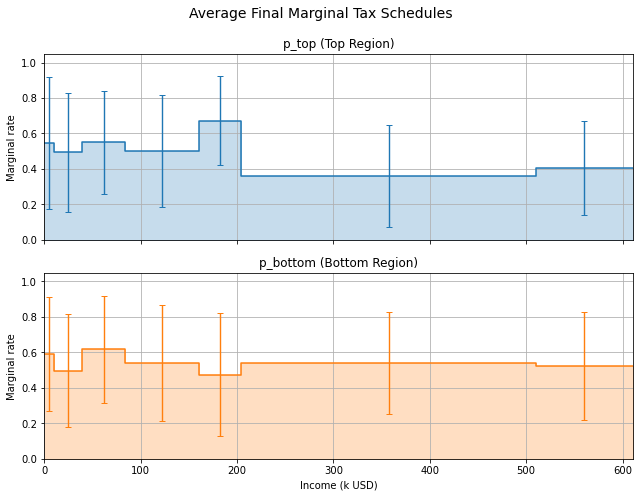

In [95]:
fig_avg_final = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules",
    errorbar="std",
    last_bin_width=100, 
)

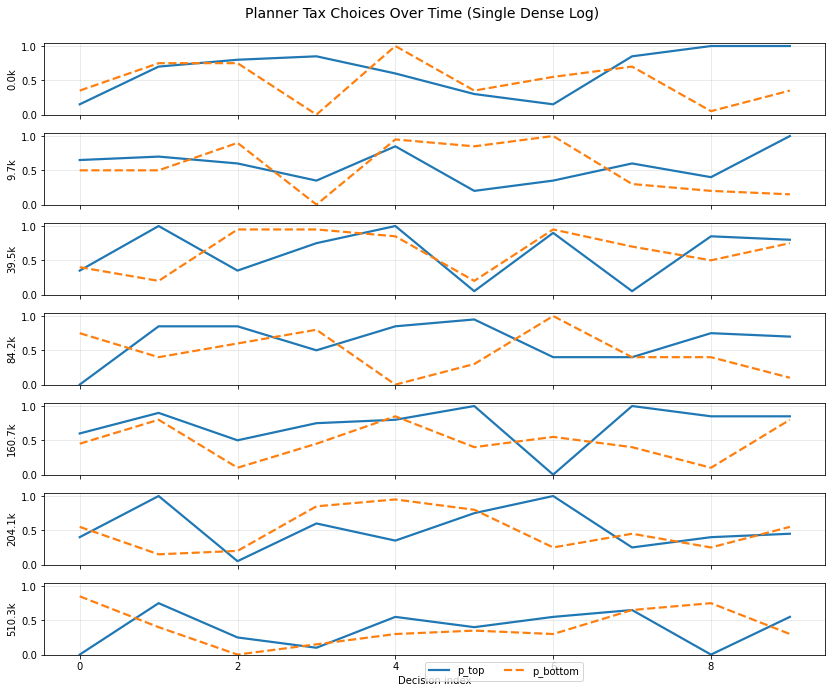

In [96]:
fig_single = plotting.plot_planner_tax_lines(
    dense_logs={0: dense_logs[0]},
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="single",
    errorbar=None,
    title="Planner Tax Choices Over Time (Single Dense Log)"
)

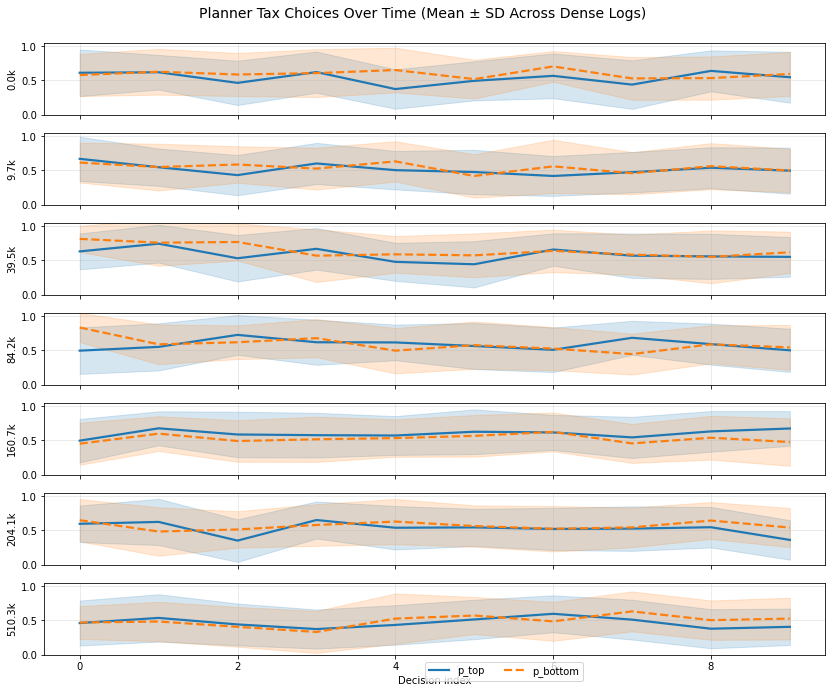

In [97]:
fig_avg = plotting.plot_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="average",
    errorbar="std",
    title="Planner Tax Choices Over Time (Mean ± SD Across Dense Logs)"
)

In [98]:
df_regions = plotting.agent_region_time_table(
    runs[2]["dense_log"],
    split_row=25,
    use_region_field=False,
    normalize=True,
)
df_regions

,timesteps_top,timesteps_bottom,total_timesteps,final_region,share_top,share_bottom
agent,,,,,,
0,59,942,1001,bottom,0.058941,0.941059
1,183,818,1001,bottom,0.182817,0.817183
2,368,633,1001,bottom,0.367632,0.632368
3,1001,0,1001,top,1.000000,0.000000
4,0,1001,1001,bottom,0.000000,1.000000
5,937,64,1001,top,0.936064,0.063936
6,777,224,1001,bottom,0.776224,0.223776
7,0,1001,1001,bottom,0.000000,1.000000


In [99]:
df_spells = plotting.agent_region_spell_table(
    runs[2]["dense_log"],
    split_row=25,
    use_region_field=False,
)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,59,942,1,1,1,59.0,942.0,500.500000,bottom
1,183,818,3,2,2,91.5,409.0,250.250000,bottom
2,368,633,1,1,1,368.0,633.0,500.500000,bottom
3,1001,0,0,1,0,1001.0,NaN,1001.000000,top
4,0,1001,0,0,1,NaN,1001.0,1001.000000,bottom
5,937,64,1,1,1,937.0,64.0,500.500000,top
6,777,224,2,1,2,777.0,112.0,333.666667,bottom
7,0,1001,0,0,1,NaN,1001.0,1001.000000,bottom


# single agent single move

In [100]:
from pathlib import Path
import pickle
import ray

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False, logging_level="ERROR")


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:63940',
 'raylet_socket_name': 'tcp://127.0.0.1:62919',
 'webui_url': 'localhost:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-05-10_15-32-25_858402_9556'}

In [101]:
import os
import glob
import json

def find_local_phase3b_checkpoint(run_dir):
    # Try common saved checkpoint locations inside your run folder
    candidates = glob.glob(os.path.join(run_dir, "**", "checkpoint-*"), recursive=True)

    # keep only actual checkpoint files, not metadata
    candidates = [
        p for p in candidates
        if os.path.isfile(p) and not p.endswith(".tune_metadata")
    ]

    if len(candidates) == 0:
        raise FileNotFoundError(f"No checkpoint-* file found inside {run_dir}")

    # choose latest checkpoint number
    def ckpt_num(path):
        base = os.path.basename(path)
        return int(base.split("-")[-1])

    return sorted(candidates, key=ckpt_num)[-1]

In [102]:
from pathlib import Path

def load_trainer_from_run(run_dir, settings):
    import json

    run_dir = Path(run_dir)  # <-- important fix

    with open(run_dir / "config.json", "r") as f:
        cfg = json.load(f)

    with open(run_dir / "checkpoints.json", "r") as f:
        ckpts = json.load(f)

    env_config = cfg["env_config_dict_phase3b"]

    env_obj = exp.create_env(env_config)

    trainer = exp.create_trainer(
        settings=settings,
        env_config_dict=env_config,
        env_obj=env_obj,
        policies_to_train=["a", "p_top", "p_bottom"],
    )
 
    local_ckpt = find_local_phase3b_checkpoint(run_dir)
    print("Restoring from:", local_ckpt)
    trainer.restore(local_ckpt)

    return trainer, env_obj

In [103]:
from utils import single

In [104]:
import os
os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1" 

from pathlib import Path, PurePosixPath
import json
import pickle
from dataclasses import fields

import ray
import simulation as exp
from utils import single

ray.shutdown()
ray.init(
    ignore_reinit_error=True,
    log_to_driver=False,
    logging_level="ERROR",
)

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"

with open(result_run_dir / "config.json", "r") as f:
    cfg = json.load(f)

with open(result_run_dir / "checkpoints.json", "r") as f:
    ckpts = json.load(f)

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

settings_from_result = exp.ExperimentSettings(**{
    f.name: cfg[f.name]
    for f in fields(exp.ExperimentSettings)
    if f.name in cfg
})

env_config = cfg["env_config_dict_phase3b"]
env_obj_phase3b = exp.create_env(env_config)


def checkpoint_ok(path):
    path = Path(path)
    return path.exists() and Path(str(path) + ".tune_metadata").exists()


def find_phase3b_checkpoint(run_dir, checkpoint_from_json):
    candidates = []

    # 1. If checkpoint files were copied into the result folder, prefer those.
    local_candidates = [
        p for p in run_dir.rglob("checkpoint-*")
        if p.is_file() and not str(p).endswith(".tune_metadata")
    ]

    def ckpt_num(path):
        try:
            return int(path.name.split("-")[-1])
        except ValueError:
            return -1

    candidates.extend(sorted(local_candidates, key=ckpt_num, reverse=True))

    # 2. Try the path exactly as stored in checkpoints.json.
    candidates.append(Path(checkpoint_from_json))

    # 3. Convert the Linux /home/.../ray_results path to this Windows user's ~/ray_results.
    posix_path = PurePosixPath(checkpoint_from_json)
    if len(posix_path.parts) >= 3:
        candidates.append(
            Path.home()
            / "ray_results"
            / posix_path.parts[-3]
            / posix_path.parts[-2]
            / posix_path.parts[-1]
        )

    tried = []
    for candidate in candidates:
        candidate = Path(candidate)
        tried.append(str(candidate))
        if checkpoint_ok(candidate):
            return candidate

    raise FileNotFoundError(
        "Could not find a valid Phase 3B checkpoint. Tried:\n"
        + "\n".join(tried)
        + "\n\nYou need the checkpoint file and its .tune_metadata file locally."
    )


checkpoint_path = find_phase3b_checkpoint(result_run_dir, ckpts["phase3b"])
print("Restoring checkpoint:", checkpoint_path)
print("Checkpoint exists:", Path(checkpoint_path).exists())
print("Metadata exists:", Path(str(checkpoint_path) + ".tune_metadata").exists())

trainer_phase3b = exp.create_trainer(
    settings=settings_from_result,
    env_config_dict=env_config,
    env_obj=env_obj_phase3b,
    policies_to_train=["a", "p_top", "p_bottom"],
)

trainer_phase3b.restore(str(checkpoint_path))
print("Restored trainer_phase3b")


FileNotFoundError: Could not find a valid Phase 3B checkpoint. Tried:
\home\adbo\ray_results\PPO_RLlibEnvWrapper_2026-05-01_02-55-29i8e7b8o_\checkpoint_1500\checkpoint-1500
C:\Users\adria\ray_results\PPO_RLlibEnvWrapper_2026-05-01_02-55-29i8e7b8o_\checkpoint_1500\checkpoint-1500

You need the checkpoint file and its .tune_metadata file locally.

In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


In [ ]:
forced_log = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_move_summary = single.forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,0,100,199,0.000,0.70,2.324930,0,0.0,0,0,0,0,0.0
1,after_move,0,201,300,2.383,23.08,3.375462,1,11.0,5,1,2,1,-9.0


In [ ]:
df_move_events = single.forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,261,61,NaN,7.35,4.0,2.0,20.49,0.421138,0,0,0,0,0
142,262,62,NaN,7.35,4.0,2.0,20.54,0.410638,0,0,0,0,0
143,263,63,NaN,7.35,4.0,2.0,20.59,0.366538,0,0,0,0,0
144,264,64,NaN,7.35,4.0,2.0,20.80,0.311938,0,0,0,0,0
145,265,65,NaN,7.35,4.0,2.0,21.06,0.267838,0,0,0,0,0
146,266,66,NaN,7.35,4.0,2.0,21.27,0.223738,0,0,0,0,0
147,267,67,NaN,7.35,4.0,2.0,21.48,0.179638,0,0,0,0,0
148,268,68,NaN,7.35,4.0,2.0,21.69,0.135538,0,0,0,0,0
149,269,69,NaN,7.35,4.0,2.0,21.90,0.091438,0,0,0,0,0
150,270,70,NaN,7.35,4.0,2.0,22.11,0.047338,0,0,0,0,0


In [ ]:
forced_log_200 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)

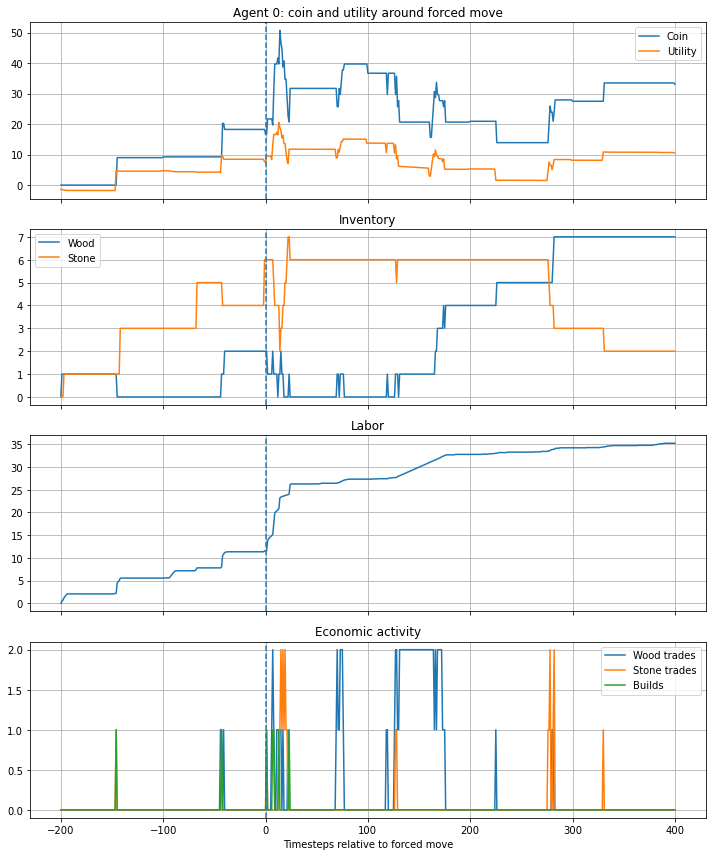

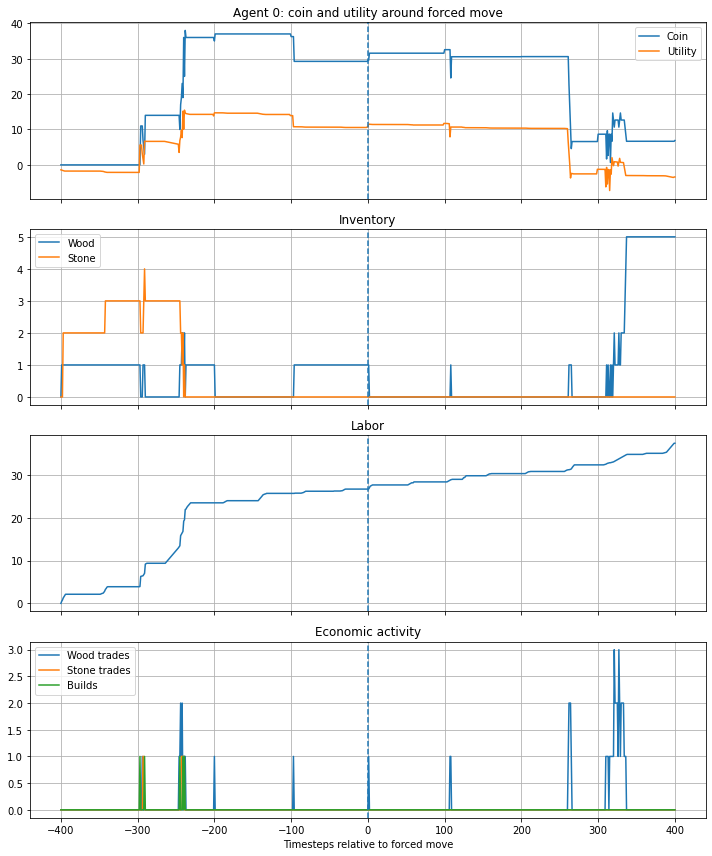

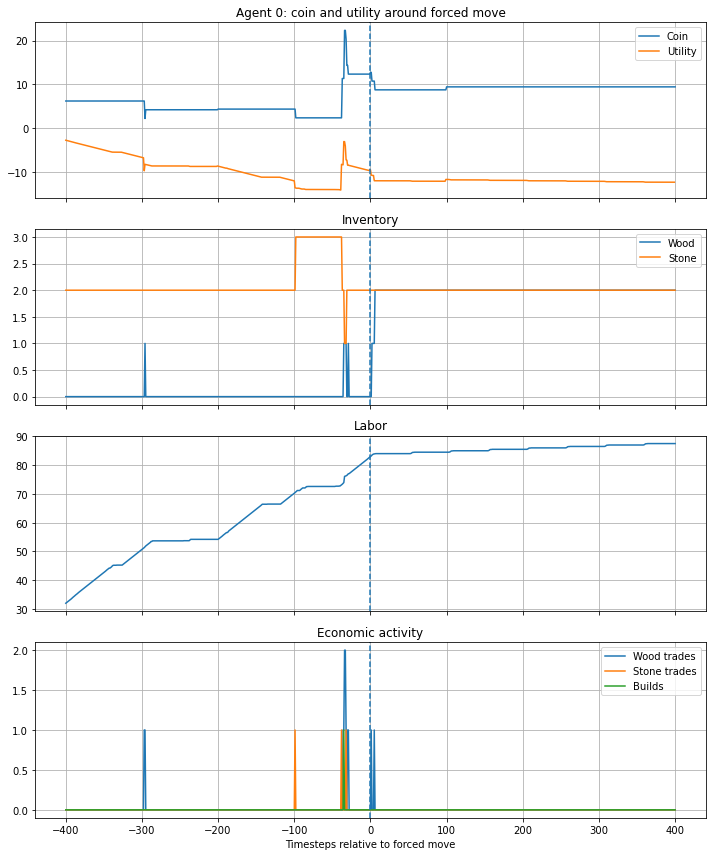

In [ ]:
fig = single.plot_forced_move_timeseries(forced_log_200, window=400)
fig = single.plot_forced_move_timeseries(forced_log_400, window=400)
fig = single.plot_forced_move_timeseries(forced_log_600, window=400)

In [ ]:
df_system = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,100,199,0.000,0.70,2.324930,0,0.0,0,0.0,0,0,0,0,NaN,NaN
1,moved_agent,after_move,1,201,300,2.383,23.08,3.375462,1,11.0,9,-9.0,5,1,2,1,NaN,NaN
2,other_agents,before_move,7,100,199,0.000,7.45,-1.155120,0,0.0,2,0.0,1,1,0,0,NaN,NaN
3,other_agents,after_move,7,201,300,34.617,37.41,-0.358317,2,26.0,43,9.0,18,22,1,2,NaN,NaN


In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = single.baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,100,199,159.000000,41.01,66.435021,10.0,110.0,26.0,49.0,3.0,7.0,4.0,12.0,NaN,NaN
1,moved_agent,after_move,1.0,201,300,110.304688,19.06,79.636680,2.0,22.0,26.0,64.0,6.0,17.0,0.0,3.0,NaN,NaN
2,other_agents,before_move,7.0,100,199,708.000000,186.75,51.400326,44.0,757.0,176.0,-49.0,42.0,38.0,52.0,44.0,NaN,NaN
3,other_agents,after_move,7.0,201,300,647.695312,180.42,71.376925,39.0,736.0,136.0,-64.0,39.0,28.0,36.0,33.0,NaN,NaN
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.189533,118.953333
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014791,101.479062
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.888942,88.894167
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.792875,79.287500


In [ ]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,159.000000,41.01,66.435021,10.0,110.0,26.0,49.0,3.0,7.0,4.0,12.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,110.304688,19.06,79.636680,2.0,22.0,26.0,64.0,6.0,17.0,0.0,3.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,708.000000,186.75,51.400326,44.0,757.0,176.0,-49.0,42.0,38.0,52.0,44.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,647.695312,180.42,71.376925,39.0,736.0,136.0,-64.0,39.0,28.0,36.0,33.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.189533,118.953333,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014791,101.479062,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.888942,88.894167,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.792875,79.287500,baseline
8,moved_agent,before_move,1.0,100,199,0.000000,0.70,2.324930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,2.383000,23.08,3.375462,1.0,11.0,9.0,-9.0,5.0,1.0,2.0,1.0,NaN,NaN,forced_move


In [ ]:
def forced_move_system_summary_table_no_planner(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,

            })


    return pd.DataFrame(rows)

In [ ]:
def baseline_system_summary_table_no_planner(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):

    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
            })

    return pd.DataFrame(rows)


In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_forced = forced_move_system_summary_table_no_planner(
    paired_forced_log,
    window_before=200,
    window_after=200,
)
df_forced["run_type"] = "forced_move"

In [ ]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table_no_planner(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=200,
    window_after=200,
)
df_baseline["run_type"] = "baseline"

In [ ]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,run_type
0,moved_agent,before_move,0,199,7.000000e+00,12.87,0.343880,1,11.0,2,-4.0,0,0,2,0,baseline
1,moved_agent,after_move,201,400,0.000000e+00,1.15,-1.329578,0,0.0,0,0.0,0,0,0,0,baseline
2,other_agents,before_move,0,199,2.600000e+01,45.93,-0.474412,2,22.0,196,4.0,96,96,1,3,baseline
3,other_agents,after_move,201,400,-3.552714e-15,41.65,0.433144,0,0.0,66,0.0,28,28,5,5,baseline
4,moved_agent,before_move,0,199,7.000000e+00,12.87,0.343880,1,11.0,2,-4.0,0,0,2,0,forced_move
5,moved_agent,after_move,201,400,1.135250e+01,5.11,2.050079,0,0.0,11,5.0,2,2,2,5,forced_move
6,other_agents,before_move,0,199,2.600000e+01,45.93,-0.474412,2,22.0,196,4.0,96,96,1,3,forced_move
7,other_agents,after_move,201,400,3.464750e+01,57.25,1.098817,4,46.0,145,-5.0,67,67,7,4,forced_move


,t,relative_t,moved_agent_utility,other_agents_avg_utility,p_top_reward,p_bottom_reward
0,100,-100,2.432345,-1.022733,NaN,NaN
1,101,-99,2.432345,-1.038333,NaN,NaN
2,102,-98,2.421845,-1.039833,NaN,NaN
3,103,-97,2.400845,-1.042833,NaN,NaN
4,104,-96,2.390345,-1.055133,NaN,NaN


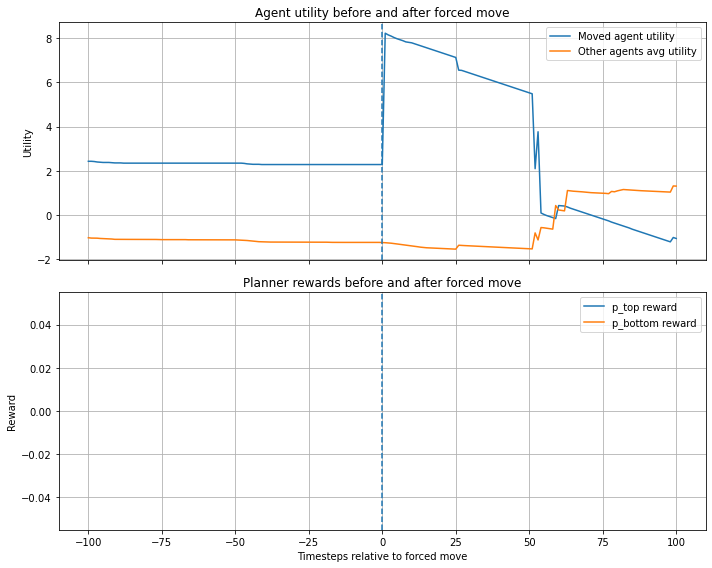

In [ ]:
fig, df_util = single.plot_forced_move_utilities_system(forced_log, window=100)
df_util.head()

In [ ]:
df_delta = single.forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0,101,101,2.383,22.38,1.050532,1,11.0,9,-9.0,5,1,2,1,NaN,NaN
1,other_agents,0,101,101,34.617,29.96,0.796803,2,26.0,41,9.0,17,21,1,2,NaN,NaN
